In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Online Retail.csv to Online Retail.csv


In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Replace with the exact filename if different
df = pd.read_csv("Online Retail.csv")

# Preview the dataset
df.head()
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  232959 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


None

In [ ]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")


Total Rows: 541909
Total Columns: 9


In [ ]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,541909.0,270954.000000,156435.797850,0.00,135477.00,270954.00,406431.00,541908.0
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [ ]:
# Summary statistics for categorical variables
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,232959,9963,12-08-2011 09:28,749
Country,541909,38,United Kingdom,495478


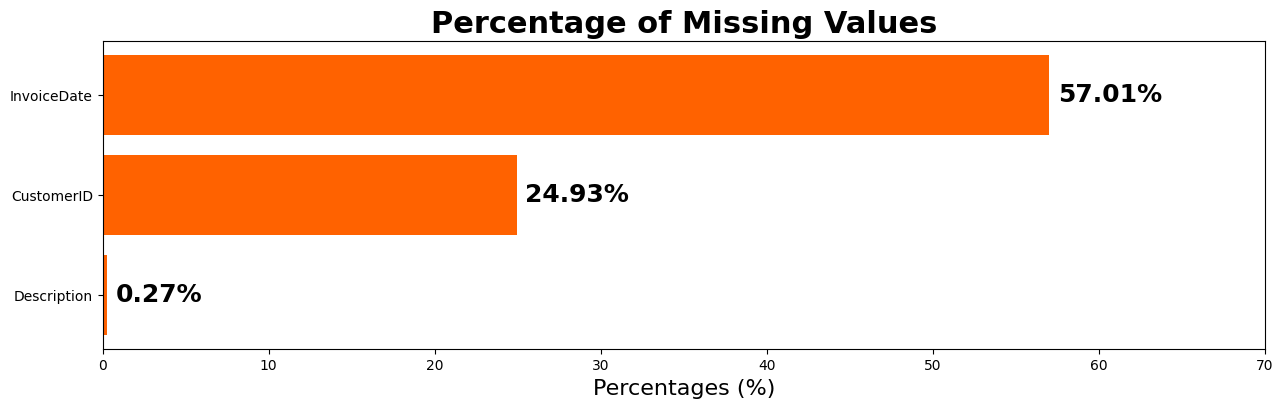

In [ ]:
# Calculating the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0,70])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [ ]:
# Extracting rows with missing values in 'CustomerID' or 'Description' columns
df[df['CustomerID'].isnull() | df['Description'].isnull()].head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,622,536414,22139,NaN,56,12-01-2010 11:52,0.00,NaN,United Kingdom
1443,1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12-01-2010 14:32,2.51,NaN,United Kingdom
1444,1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12-01-2010 14:32,2.51,NaN,United Kingdom
1445,1445,536544,21786,POLKADOT RAIN HAT,4,12-01-2010 14:32,0.85,NaN,United Kingdom
1446,1446,536544,21787,RAIN PONCHO RETROSPOT,2,12-01-2010 14:32,1.66,NaN,United Kingdom


In [ ]:
### Preprocessing ###
# Drop unnecessary index column if exists
df.drop(columns=['index'], errors='ignore', inplace=True)

In [ ]:
# Handling missing values
df.dropna(subset=['CustomerID'], inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
# Drop missing values in important columns
df.dropna(subset=['CustomerID', 'InvoiceDate'], inplace=True)

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')


In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# Removing negative quantities
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
# Remove negative or zero quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [ ]:
# Removing rows with missing values in 'CustomerID' and 'Description' columns
df = df.dropna(subset=['CustomerID', 'Description'])

In [ ]:
# Verifying the removal of missing values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
 # Displaying the number of duplicate rows
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

# Removing duplicate rows
df.drop_duplicates(inplace=True)

The dataset contains 0 duplicate rows that need to be removed.


In [ ]:
# Filter out the rows with InvoiceNo starting with "C" and create a new column indicating the transaction status
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

# Analyze the characteristics of these rows (considering the new column)
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancelled_transactions.describe().drop('CustomerID', axis=1)

,Quantity,InvoiceDate,UnitPrice
count,0.0,0,0.0
mean,NaN,NaT,NaN
min,NaN,NaT,NaN
25%,NaN,NaT,NaN
50%,NaN,NaT,NaN
75%,NaN,NaT,NaN
max,NaN,NaT,NaN
std,NaN,NaN,NaN


In [ ]:
# Finding the percentage of cancelled transactions
cancelled_percentage = (cancelled_transactions.shape[0] / df.shape[0]) * 100

# Printing the percentage of cancelled transactions
print(f"The percentage of cancelled transactions in the dataset is: {cancelled_percentage:.2f}%")

The percentage of cancelled transactions in the dataset is: 0.00%


In [ ]:
# Finding the number of unique stock codes
unique_stock_codes = df['StockCode'].nunique()

# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3507


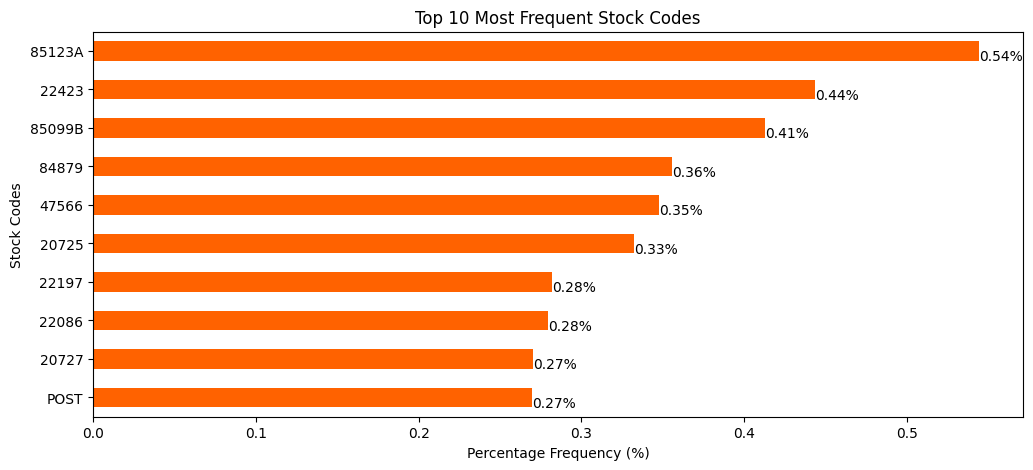

In [ ]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df['StockCode'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3502
0       4
1       1
Name: count, dtype: int64


In [ ]:
# Finding and printing the stock codes with 0 and 1 numeric characters
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
C2
M
BANK CHARGES
DOT


In [ ]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# Printing the percentage
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.38%


In [ ]:
# Removing rows with anomalous stock codes from the dataset
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

165727

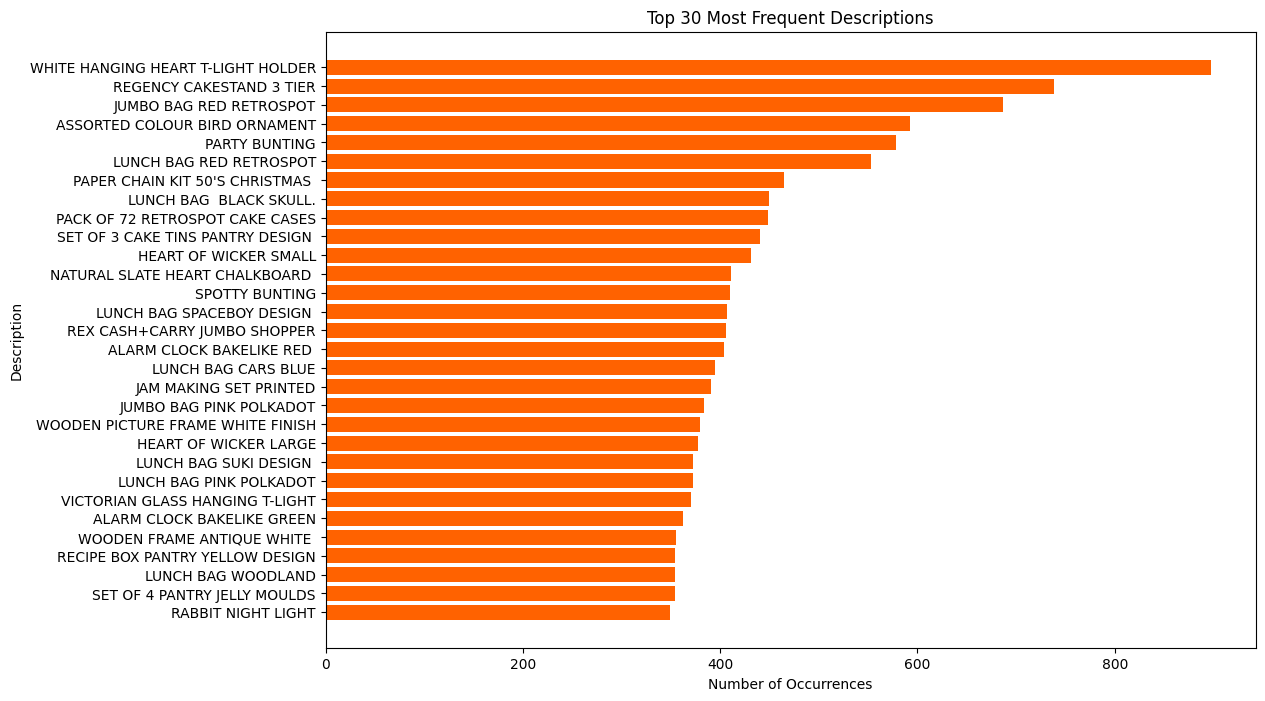

In [ ]:
# Calculate the occurrence of each unique description and sort them
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')

# Show the plot
plt.show()

In [ ]:
# Find unique descriptions containing lowercase characters
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
NUMBER TILE COTTAGE GARDEN No
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


In [ ]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Calculate the percentage of records with service-related descriptions
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# Print the percentage of records with service-related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Remove rows with service-related information in the description
df = df[~df['Description'].isin(service_related_descriptions)]

# Standardize the text to uppercase to maintain uniformity across the dataset
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


<ipython-input-29-478a31da65ee>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Description'] = df['Description'].str.upper()


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

165696

In [ ]:
df['UnitPrice'].describe()

,UnitPrice
count,165696.000000
mean,2.871356
std,4.610661
min,0.040000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [ ]:
df[df['UnitPrice']==0].describe()[['Quantity']]

,Quantity
count,0.0
mean,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN
std,NaN


In [ ]:
# Resetting the index of the cleaned dataset
df.reset_index(drop=True, inplace=True)

In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

165696

In [ ]:
# Recency
# Convert InvoiceDate to datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert InvoiceDate to datetime and extract only the date
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Find the most recent purchase date for each customer
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df['InvoiceDay'].max()

# Convert InvoiceDay to datetime type before subtraction
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchase for each customer
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Remove the InvoiceDay column
customer_data.drop(columns=['InvoiceDay'], inplace=True)

In [ ]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase
0,12347.0,2
1,12348.0,248
2,12350.0,310
3,12352.0,36
4,12355.0,214


In [ ]:
# Frequency
# Calculate the total number of transactions made by each customer
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12347.0,2,5,1467
1,12348.0,248,1,268
2,12350.0,310,1,196
3,12352.0,36,2,150
4,12355.0,214,1,240


In [ ]:
# Monetary
# Calculate the total spend by each customer
df['Total_Spend'] = df['UnitPrice'] * df['Quantity']
total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on='CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12347.0,2,5,1467,2540.29,508.058
1,12348.0,248,1,268,327.00,327.000
2,12350.0,310,1,196,294.40,294.400
3,12352.0,36,2,150,336.08,168.040
4,12355.0,214,1,240,459.40,459.400


In [ ]:
# Calculate the number of unique products purchased by each customer
unique_products_purchased = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_products_purchased.rename(columns={'StockCode': 'Unique_Products_Purchased'}, inplace=True)

# Merge the new feature into the customer_data dataframe
customer_data = pd.merge(customer_data, unique_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12347.0,2,5,1467,2540.29,508.058,79
1,12348.0,248,1,268,327.00,327.000,4
2,12350.0,310,1,196,294.40,294.400,16
3,12352.0,36,2,150,336.08,168.040,18
4,12355.0,214,1,240,459.40,459.400,13


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# Extract day of week and hour from InvoiceDate
df['Day_Of_Week'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Calculate the average number of days between consecutive purchases
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)

# Find the favorite shopping day of the week
favorite_shopping_day = df.groupby(['CustomerID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]

# Find the favorite shopping hour of the day
favorite_shopping_hour = df.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, average_days_between_purchases, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

<ipython-input-41-17c40a44c6d4>:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))


,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12347.0,2,5,1467,2540.29,508.058,79,3.476190,1,14
1,12348.0,248,1,268,327.00,327.000,4,0.000000,1,10
2,12350.0,310,1,196,294.40,294.400,16,0.000000,2,16
3,12352.0,36,2,150,336.08,168.040,18,14.529412,3,14
4,12355.0,214,1,240,459.40,459.400,13,0.000000,0,13


In [ ]:
df['Country'].value_counts(normalize=True).head()

,proportion
Country,
United Kingdom,0.893745
France,0.022722
Germany,0.021449
EIRE,0.016645
Spain,0.005806


In [ ]:
# Group by CustomerID and Country to get the number of transactions per country for each customer
customer_country = df.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')

# Get the country with the maximum number of transactions for each customer (in case a customer has transactions from multiple countries)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('CustomerID')

# Create a binary column indicating whether the customer is from the UK or not
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Merge this data with our customer_data dataframe
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'Is_UK']], on='CustomerID', how='left')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK
0,12347.0,2,5,1467,2540.29,508.058,79,3.476190,1,14,0
1,12348.0,248,1,268,327.00,327.000,4,0.000000,1,10,0
2,12350.0,310,1,196,294.40,294.400,16,0.000000,2,16,0
3,12352.0,36,2,150,336.08,168.040,18,14.529412,3,14,0
4,12355.0,214,1,240,459.40,459.400,13,0.000000,0,13,0


In [ ]:
# Display feature distribution
customer_data['Is_UK'].value_counts()

,count
Is_UK,
1,2637
0,278


In [ ]:
# Calculate the total number of transactions made by each customer
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Ensure 'CustomerID' is of the same data type in both DataFrames
customer_data['CustomerID'] = customer_data['CustomerID'].astype(float)  # or total_transactions['CustomerID'].astype(str)
total_transactions['CustomerID'] = total_transactions['CustomerID'].astype(float) # or customer_data['CustomerID'].astype(str)
total_products_purchased['CustomerID'] = total_products_purchased['CustomerID'].astype(float) # or customer_data['CustomerID'].astype(str)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y
0,12347.0,2,5,1467,2540.29,508.058,79,3.476190,1,14,0,5,1467
1,12348.0,248,1,268,327.00,327.000,4,0.000000,1,10,0,1,268
2,12350.0,310,1,196,294.40,294.400,16,0.000000,2,16,0,1,196
3,12352.0,36,2,150,336.08,168.040,18,14.529412,3,14,0,2,150
4,12355.0,214,1,240,459.40,459.400,13,0.000000,0,13,0,1,240


In [ ]:
from scipy.stats import linregress  # Import linregress explicitly

In [ ]:
# Extract month and year from InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Calculate monthly spending for each customer
monthly_spending = df.groupby(['CustomerID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()

# Calculate Seasonal Buying Patterns: We are using monthly frequency as a proxy for seasonal buying patterns
seasonal_buying_patterns = monthly_spending.groupby('CustomerID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

# Replace NaN values in Monthly_Spending_Std with 0, implying no variability for customers with single transaction month
seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)

# Calculate Trends in Spending
# We are using the slope of the linear trend line fitted to the customer's spending over time as an indicator of spending trends
def calculate_trend(spend_data):
    # If there are more than one data points, we calculate the trend using linear regression
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    # If there is only one data point, no trend can be calculated, hence we return 0
    else:
        return 0

# Apply the calculate_trend function to find the spending trend for each customer
spending_trends = monthly_spending.groupby('CustomerID')['Total_Spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'Total_Spend': 'Spending_Trend'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='CustomerID')
customer_data = pd.merge(customer_data, spending_trends, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()


<ipython-input-47-e4ff22a0fb13>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0, inplace=True)


,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,2,5,1467,2540.29,508.058,79,3.476190,1,14,0,5,1467,508.058,199.893535,-102.528
1,12348.0,248,1,268,327.00,327.000,4,0.000000,1,10,0,1,268,327.000,0.000000,0.000
2,12350.0,310,1,196,294.40,294.400,16,0.000000,2,16,0,1,196,294.400,0.000000,0.000
3,12352.0,36,2,150,336.08,168.040,18,14.529412,3,14,0,2,150,168.040,90.071262,127.380
4,12355.0,214,1,240,459.40,459.400,13,0.000000,0,13,0,1,240,459.400,0.000000,0.000


In [ ]:
# Changing the data type of 'CustomerID' to string as it is a unique identifier and not used in mathematical operations
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)

# Convert data types of columns to optimal types
customer_data = customer_data.convert_dtypes()

In [ ]:
customer_data.head(10)

,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,2,5,1467,2540.29,508.058,79,3.47619,1,14,0,5,1467,508.058,199.893535,-102.528
1,12348.0,248,1,268,327.0,327.0,4,0.0,1,10,0,1,268,327.0,0.0,0.0
2,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,1,196,294.4,0.0,0.0
3,12352.0,36,2,150,336.08,168.04,18,14.529412,3,14,0,2,150,168.04,90.071262,127.38
4,12355.0,214,1,240,459.4,459.4,13,0.0,0,13,0,1,240,459.4,0.0,0.0
5,12356.0,245,1,370,481.46,481.46,21,0.0,4,12,0,1,370,481.46,0.0,0.0
6,12357.0,33,1,2708,6207.67,6207.67,131,0.0,6,16,0,1,2708,6207.67,0.0,0.0
7,12358.0,1,2,242,928.06,464.03,12,9.3125,1,10,0,2,242,464.03,83.679016,118.34
8,12359.0,189,3,965,3495.73,1165.243333,135,1.0,0,14,0,3,965,1165.243333,647.518734,280.91
9,12362.0,3,5,1063,1916.79,383.358,91,1.461538,3,15,0,5,1063,383.358,81.544933,39.625


In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      2915 non-null   string 
 1   Days_Since_Last_Purchase        2915 non-null   Int64  
 2   Total_Transactions_x            2915 non-null   Int64  
 3   Total_Products_Purchased_x      2915 non-null   Int64  
 4   Total_Spend                     2915 non-null   Float64
 5   Average_Transaction_Value       2915 non-null   Float64
 6   Unique_Products_Purchased       2915 non-null   Int64  
 7   Average_Days_Between_Purchases  2915 non-null   Float64
 8   Day_Of_Week                     2915 non-null   Int32  
 9   Hour                            2915 non-null   Int32  
 10  Is_UK                           2915 non-null   Int64  
 11  Total_Transactions_y            2915 non-null   Int64  
 12  Total_Products_Purchased_y      29

In [ ]:
# Initializing the IsolationForest model with a contamination parameter of 0.05
model = IsolationForest(contamination=0.05, random_state=0)

# Replace NaT values with NaNs
customer_data_numeric = customer_data.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
# Instead of using to_numpy, fill NaNs with a suitable value before fitting
customer_data['Outlier_Scores'] = model.fit_predict(customer_data_numeric.fillna(-999)) # Filling with -999 or any other suitable placeholder

# Creating a new column to identify outliers (1 for inliers and -1 for outliers)
customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_Scores']]

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,12347.0,2,5,1467,2540.29,508.058,79,3.47619,1,14,0,5,1467,508.058,199.893535,-102.528,1,0
1,12348.0,248,1,268,327.0,327.0,4,0.0,1,10,0,1,268,327.0,0.0,0.0,1,0
2,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,1,196,294.4,0.0,0.0,1,0
3,12352.0,36,2,150,336.08,168.04,18,14.529412,3,14,0,2,150,168.04,90.071262,127.38,1,0
4,12355.0,214,1,240,459.4,459.4,13,0.0,0,13,0,1,240,459.4,0.0,0.0,1,0


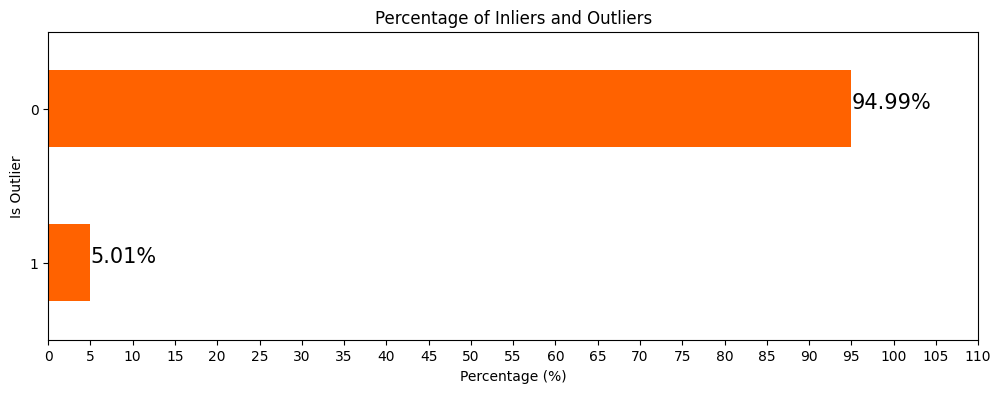

In [ ]:
# Calculate the percentage of inliers and outliers
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100

# Plotting the percentage of inliers and outliers
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh', color='#ff6200')

# Adding the percentage labels on the bars
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%', fontsize=15)

plt.title('Percentage of Inliers and Outliers')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Separate the outliers for analysis
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]

# Remove the outliers from the main dataset
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]

# Drop the 'Outlier_Scores' and 'Is_Outlier' columns
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])

# Reset the index of the cleaned data
customer_data_cleaned.reset_index(drop=True, inplace=True)

In [ ]:
# Getting the number of rows in the cleaned customer dataset
customer_data_cleaned.shape[0]

2769

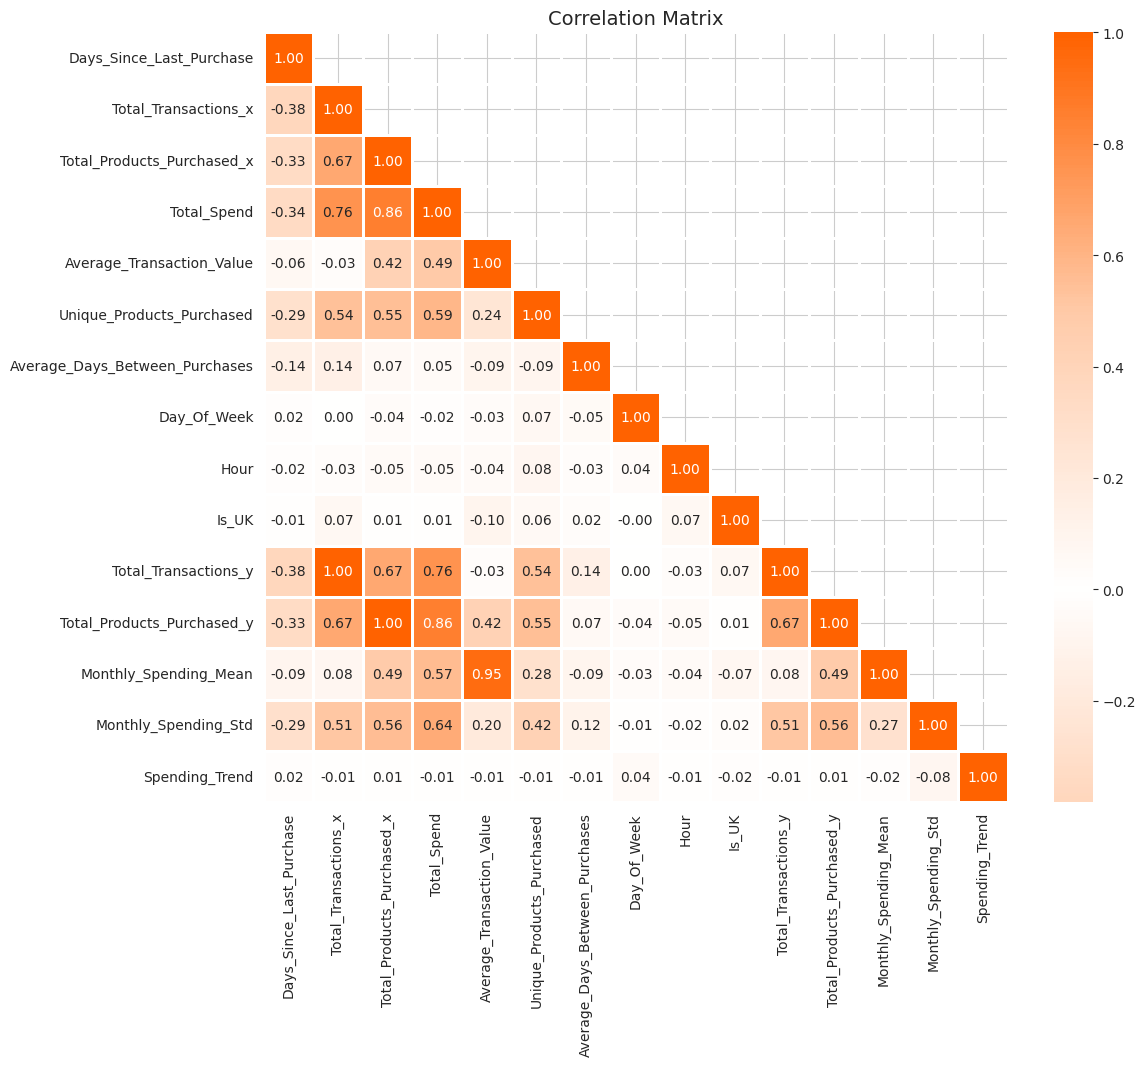

In [ ]:
# Reset background style
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
sns.set_style('whitegrid')

# Calculate the correlation matrix excluding the 'CustomerID' column
corr = customer_data_cleaned.drop(columns=['CustomerID']).corr()

# Define a custom colormap
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Create a mask to only show the lower triangle of the matrix (since it's mirrored around its
# top-left to bottom-right diagonal)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# List of columns that don't need to be scaled
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']

# List of columns that need to be scaled
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

# Copy the cleaned dataset
customer_data_scaled = customer_data_cleaned.copy()

# Applying the scaler to the necessary columns in the dataset
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

# Display the first few rows of the scaled data
customer_data_scaled.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,-1.043433,1.463359,2.089746,2.416506,0.728244,0.929482,0.086442,1,0.656108,0,1.463359,2.089746,0.579084,1.188351,-0.756292
1,12348.0,1.126414,-0.653971,-0.336683,-0.526670,-0.009146,-0.847420,-0.319399,1,-1.067167,0,-0.653971,-0.336683,-0.107348,-0.573077,0.029058
2,12350.0,1.673286,-0.653971,-0.482390,-0.570021,-0.141916,-0.563116,-0.319399,2,1.517745,0,-0.653971,-0.482390,-0.230941,-0.573077,0.029058
3,12352.0,-0.743535,-0.124639,-0.575481,-0.514596,-0.656539,-0.515732,1.376893,3,0.656108,0,-0.124639,-0.575481,-0.710000,0.220616,1.004770
4,12355.0,0.826516,-0.653971,-0.393347,-0.350608,0.530075,-0.634192,-0.319399,0,0.225289,0,-0.653971,-0.393347,0.394610,-0.573077,0.029058


In [ ]:
# Step 1: Prepare your dataset
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # Ensure datetime
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Step 2: Compute RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Quantity': 'sum'                                          # Monetary (approx)
}).reset_index()

# Step 3: Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Step 4: Optional - Drop missing values
rfm.dropna(inplace=True)

# Step 5: Create clusters (if not already done)
# Use KMeans or another clustering method
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm[['Recency', 'Frequency', 'Monetary']])

from sklearn.preprocessing import StandardScaler





In [ ]:
# Extract features and scale
features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm[features])

# Create a new DataFrame and include CustomerID for reference
customer_data_scaled = pd.DataFrame(scaled_features, columns=features)
customer_data_scaled['CustomerID'] = rfm['CustomerID'].values



Number of components explaining ≥ 95% variance: 1


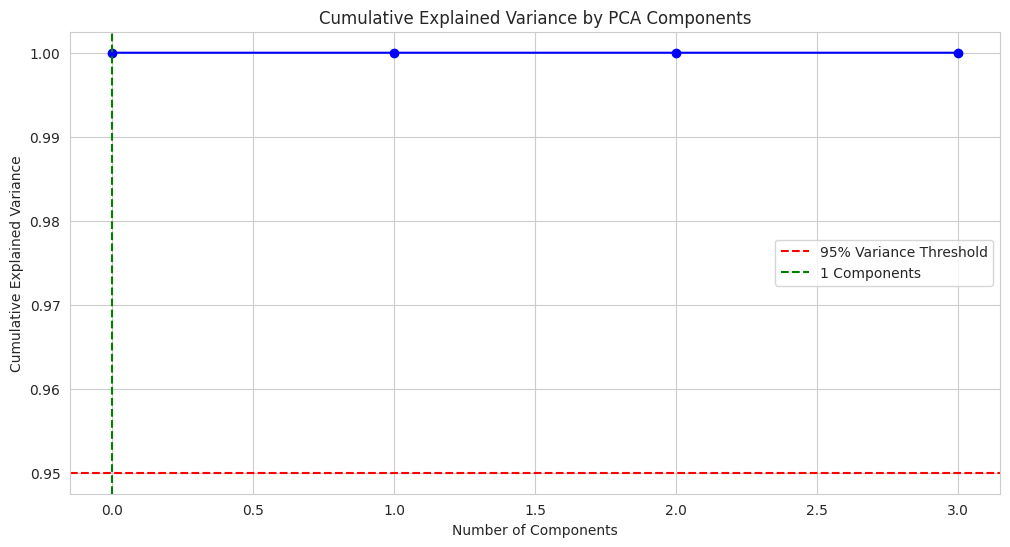

In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer



from sklearn.decomposition import PCA

# Fit PCA on the scaled customer data
pca = PCA().fit(customer_data_scaled)

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Automatically select the number of components that explain >= 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 because index starts at 0

print(f"Number of components explaining ≥ 95% variance: {n_components_95}")

# Optional: Refit PCA with only the selected number of components
pca_final = PCA(n_components=n_components_95)
customer_data_pca = pca_final.fit_transform(customer_data_scaled)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-', color='blue')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(x=n_components_95-1, color='g', linestyle='--', label=f'{n_components_95} Components')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()






In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Drop columns with all NaN values
customer_data_scaled_cleaned = customer_data_scaled.dropna(axis=1, how='all')

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
customer_data_scaled_imputed = imputer.fit_transform(customer_data_scaled_cleaned)

# Automatically choose the number of components to retain 95% variance
pca_temp = PCA().fit(customer_data_scaled_imputed)
cumulative_variance = np.cumsum(pca_temp.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Using {n_components_95} components to retain ≥ 95% variance.")

# Re-run PCA with optimal components
pca = PCA(n_components=n_components_95)
customer_data_pca = pca.fit_transform(customer_data_scaled_imputed)

# Create PCA DataFrame
customer_data_pca = pd.DataFrame(customer_data_pca, columns=[f'PC{i+1}' for i in range(n_components_95)])

# Add CustomerID index back
customer_data_pca.index = customer_data_scaled.index



Using 1 components to retain ≥ 95% variance.


In [ ]:
# Displaying the resulting dataframe based on the PCs
customer_data_pca.head()

,PC1
0,-2943.403490
1,-2942.403468
2,-2940.403463
3,-2938.403485
4,-2935.403471


In [ ]:
# Use the actual feature names passed to PCA
valid_features = customer_data_scaled_cleaned.columns  # Get feature names from the scaled data

# Create the PCA component DataFrame
pc_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC{}'.format(i+1) for i in range(pca.n_components_)],
    index=valid_features
)

# Define the highlight function
def highlight_top3(column):
    top3 = column.abs().nlargest(3).index
    return ['background-color:  #ff9800' if i in top3 else '' for i in column.index]

# Apply styling
pc_df.style.apply(highlight_top3, axis=0)


,PC1
Recency,0.000009
Frequency,0.000000
Monetary,-0.000003
CustomerID,1.000000


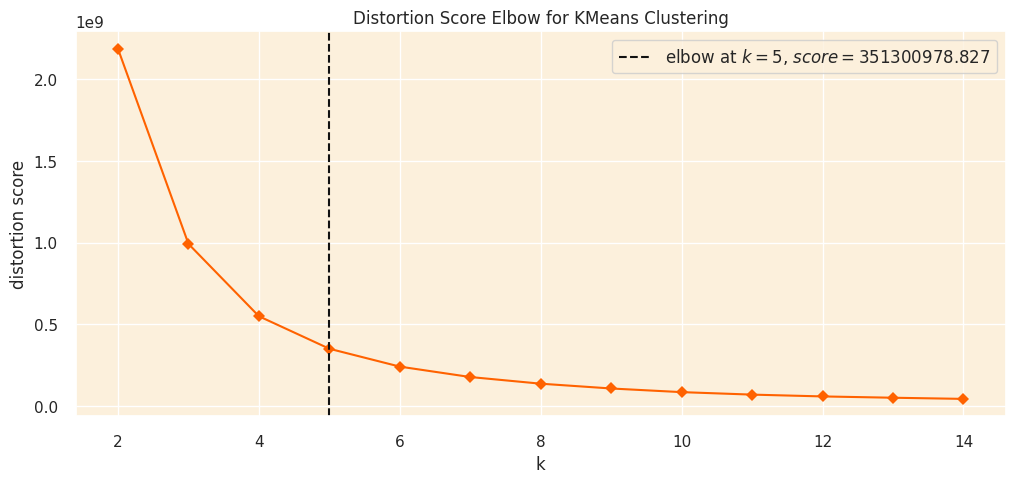

In [ ]:

# Kmeans Clustering
# Set plot style, and background color
import matplotlib.pyplot as plt  # Make sure matplotlib.pyplot is imported
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer  # Import KElbowVisualizer
sns.set(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})

# Set the color palette for the plot
sns.set_palette(['#ff6200'])

# Instantiate the clustering model with the specified parameters
km = KMeans(init='k-means++', n_init=10, max_iter=100, random_state=0)

# Create a figure and axis with the desired size
fig, ax = plt.subplots(figsize=(12, 5))

# Instantiate the KElbowVisualizer with the model and range of k values, and disable the timing plot
visualizer = KElbowVisualizer(km, k=(2, 15), timings=False, ax=ax)

# Fit the data to the visualizer
visualizer.fit(customer_data_pca)

# Finalize and render the figure
visualizer.show();

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec # Add this line to import gridspec
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
def silhouette_analysis(df, start_k, stop_k, figsize=(15, 16)):
    """
    Perform Silhouette analysis for a range of k values and visualize the results.
    """

    # Set the size of the figure
    plt.figure(figsize=figsize)

    # Create a grid with (stop_k - start_k + 1) rows and 2 columns
    grid = gridspec.GridSpec(stop_k - start_k + 1, 2)

    # Assign the first plot to the first row and both columns
    first_plot = plt.subplot(grid[0, :])

    # First plot: Silhouette scores for different k values
    sns.set_palette(['darkorange'])

    silhouette_scores = []

    # Iterate through the range of k values
    for k in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=0)
        km.fit(df)
        labels = km.predict(df)
        score = silhouette_score(df, labels)
        silhouette_scores.append(score)

    best_k = start_k + silhouette_scores.index(max(silhouette_scores))

    plt.plot(range(start_k, stop_k + 1), silhouette_scores, marker='o')
    plt.xticks(range(start_k, stop_k + 1))
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.title('Average Silhouette Score for Different k Values', fontsize=15)

    # Add the optimal k value text to the plot
    optimal_k_text = f'The k value with the highest Silhouette score is: {best_k}'
    plt.text(10, 0.23, optimal_k_text, fontsize=12, verticalalignment='bottom',
             horizontalalignment='left', bbox=dict(facecolor='#fcc36d', edgecolor='#ff6200', boxstyle='round, pad=0.5'))


    # Second plot (subplot): Silhouette plots for each k value
    colors = sns.color_palette("bright")

    for i in range(start_k, stop_k + 1):
        km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=0)
        row_idx, col_idx = divmod(i - start_k, 2)

        # Assign the plots to the second, third, and fourth rows
        ax = plt.subplot(grid[row_idx + 1, col_idx])

        visualizer = SilhouetteVisualizer(km, colors=colors, ax=ax)
        visualizer.fit(df)

        # Add the Silhouette score text to the plot
        score = silhouette_score(df, km.labels_)
        ax.text(0.97, 0.02, f'Silhouette Score: {score:.2f}', fontsize=12, \
                ha='right', transform=ax.transAxes, color='red')

        ax.set_title(f'Silhouette Plot for {i} Clusters', fontsize=15)

    plt.tight_layout()
    plt.show()

<ipython-input-64-f525f89b4a49>:68: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


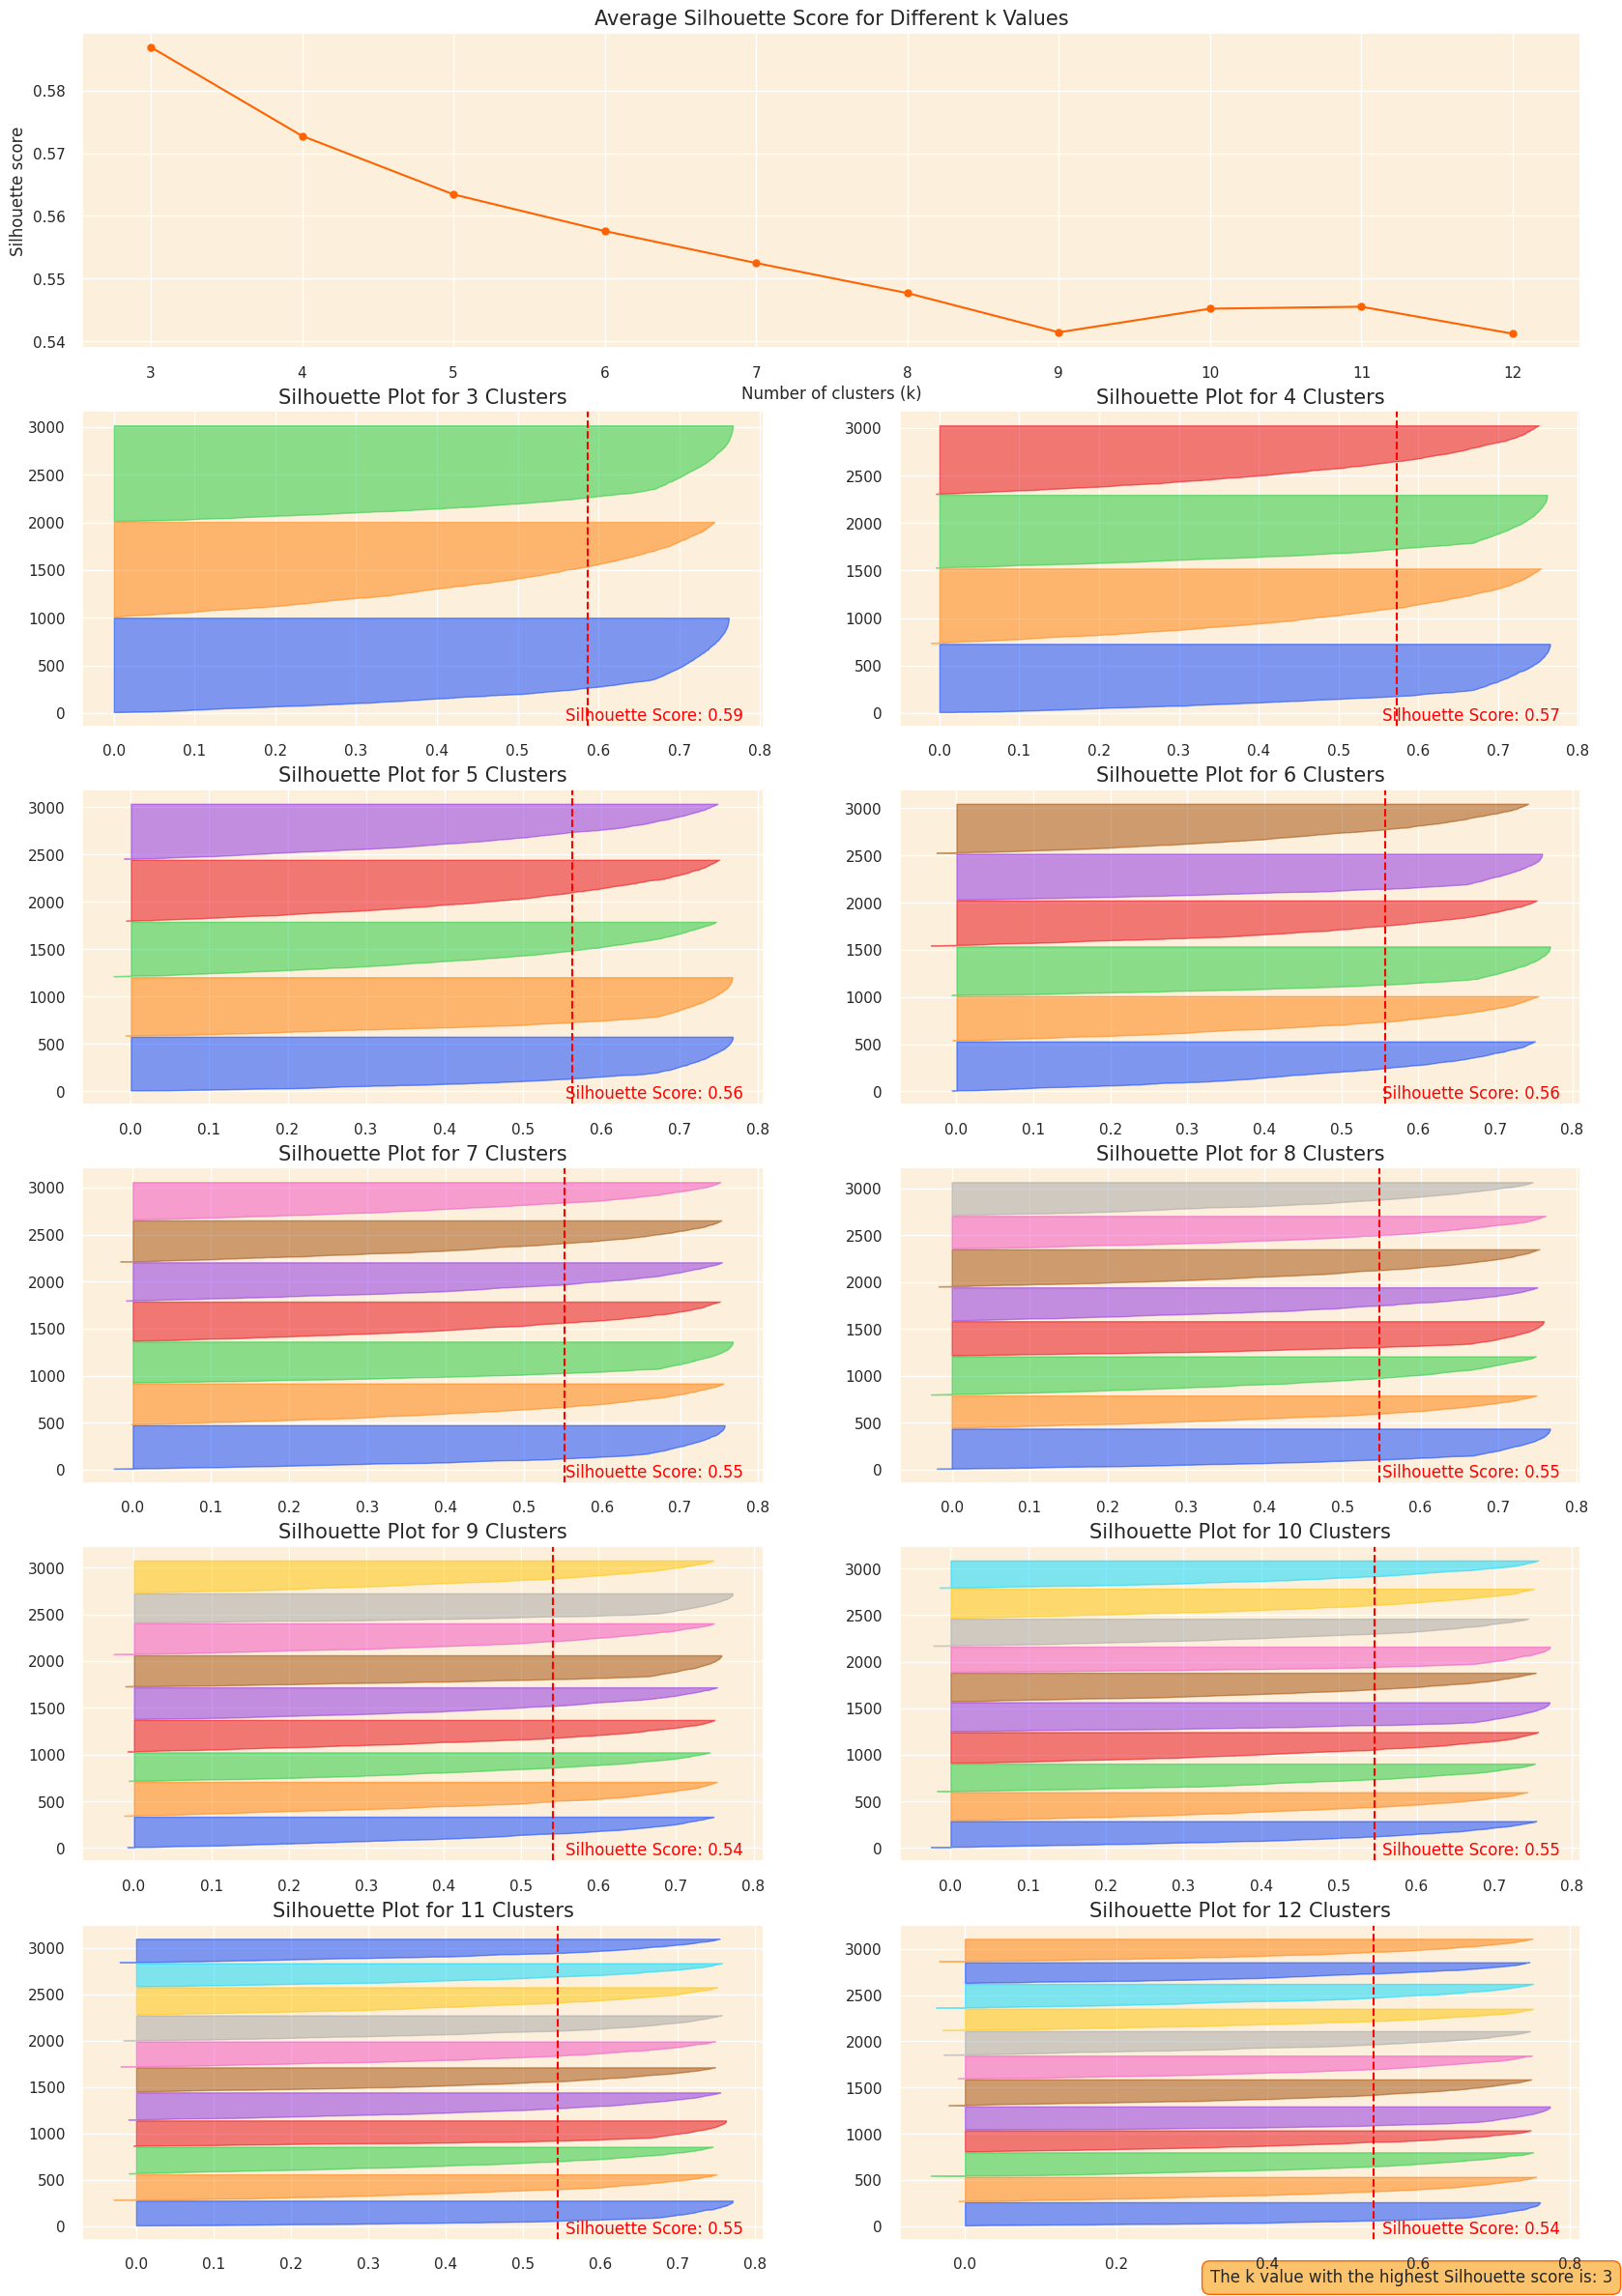

In [ ]:
silhouette_analysis(customer_data_pca, 3, 12, figsize=(20, 50))

In [ ]:
from collections import Counter  # Import Counter from collections
# Apply KMeans clustering using the optimal k
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(customer_data_pca)

# Get the frequency of each cluster
cluster_frequencies = Counter(kmeans.labels_)

# Create a mapping from old labels to new labels based on frequency
label_mapping = {label: new_label for new_label, (label, _) in
                 enumerate(cluster_frequencies.most_common())}

# Reverse the mapping to assign labels as per your criteria
label_mapping = {v: k for k, v in {2: 1, 1: 0, 0: 2}.items()}

# Apply the mapping to get the new labels
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])



# Append the new cluster labels to the PCA version of the dataset
customer_data_pca['cluster'] = new_labels

# Merge clusters back into RFM using CustomerID as the key
rfm_clustered = rfm.merge(customer_data_pca[['cluster']], left_on='CustomerID', right_index=True, how='left')


In [ ]:
# Display the first few rows of the original dataframe
customer_data_cleaned.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions_x,Total_Products_Purchased_x,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Total_Transactions_y,Total_Products_Purchased_y,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,2,5,1467,2540.29,508.058,79,3.47619,1,14,0,5,1467,508.058,199.893535,-102.528
1,12348.0,248,1,268,327.0,327.0,4,0.0,1,10,0,1,268,327.0,0.0,0.0
2,12350.0,310,1,196,294.4,294.4,16,0.0,2,16,0,1,196,294.4,0.0,0.0
3,12352.0,36,2,150,336.08,168.04,18,14.529412,3,14,0,2,150,168.04,90.071262,127.38
4,12355.0,214,1,240,459.4,459.4,13,0.0,0,13,0,1,240,459.4,0.0,0.0


In [ ]:
# Setting up the color scheme for the clusters (RGB order)
colors = ['#e8000b', '#1ac938', '#023eff']

In [ ]:
# Create separate data frames for each cluster
import plotly.graph_objects as go
# Import the plotly.graph_objects module and assign it to the alias 'go'
cluster_0 = customer_data_pca[customer_data_pca['cluster'] == 0]
cluster_1 = customer_data_pca[customer_data_pca['cluster'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['cluster'] == 2]



<ipython-input-70-4e2adce43589>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors)


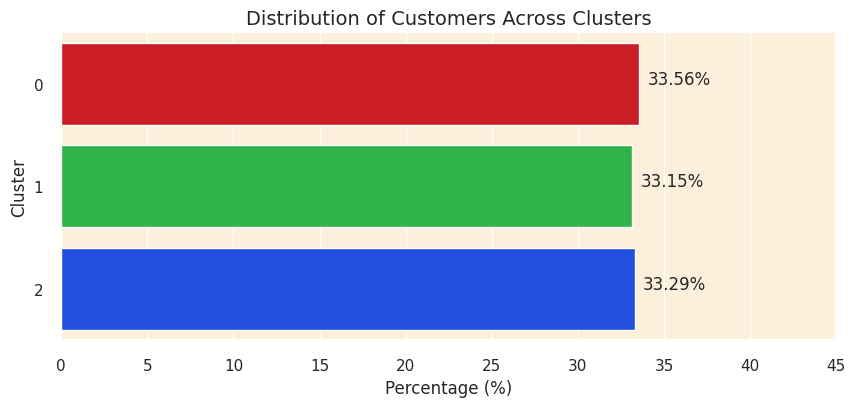

In [ ]:
# Calculate the percentage of customers in each cluster
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()
cluster_percentage.columns = ['Cluster', 'Percentage']
cluster_percentage.sort_values(by='Cluster', inplace=True)

# Create a horizontal bar plot
plt.figure(figsize=(10, 4))
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors)

# Adding percentages on the bars
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')

plt.title('Distribution of Customers Across Clusters', fontsize=14)
plt.xticks(ticks=np.arange(0, 50, 5))
plt.xlabel('Percentage (%)')

# Show the plot
plt.show()

In [ ]:
# Compute number of customers
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score # Import necessary functions
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]

# Print the table
from tabulate import tabulate # Make sure tabulate is imported
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+--------------------+
|         Metric          |       Value        |
+-------------------------+--------------------+
| Number of Observations  |        2989        |
|    Silhouette Score     | 0.5869180676701929 |
| Calinski Harabasz Score | 11849.835784262239 |
|  Davies Bouldin Score   | 0.5089814827825101 |
+-------------------------+--------------------+


Length of new_labels: 2989
Shape of customer_data_cleaned: (2769, 16)
❗ Length mismatch detected. Aligning by row position using iloc.


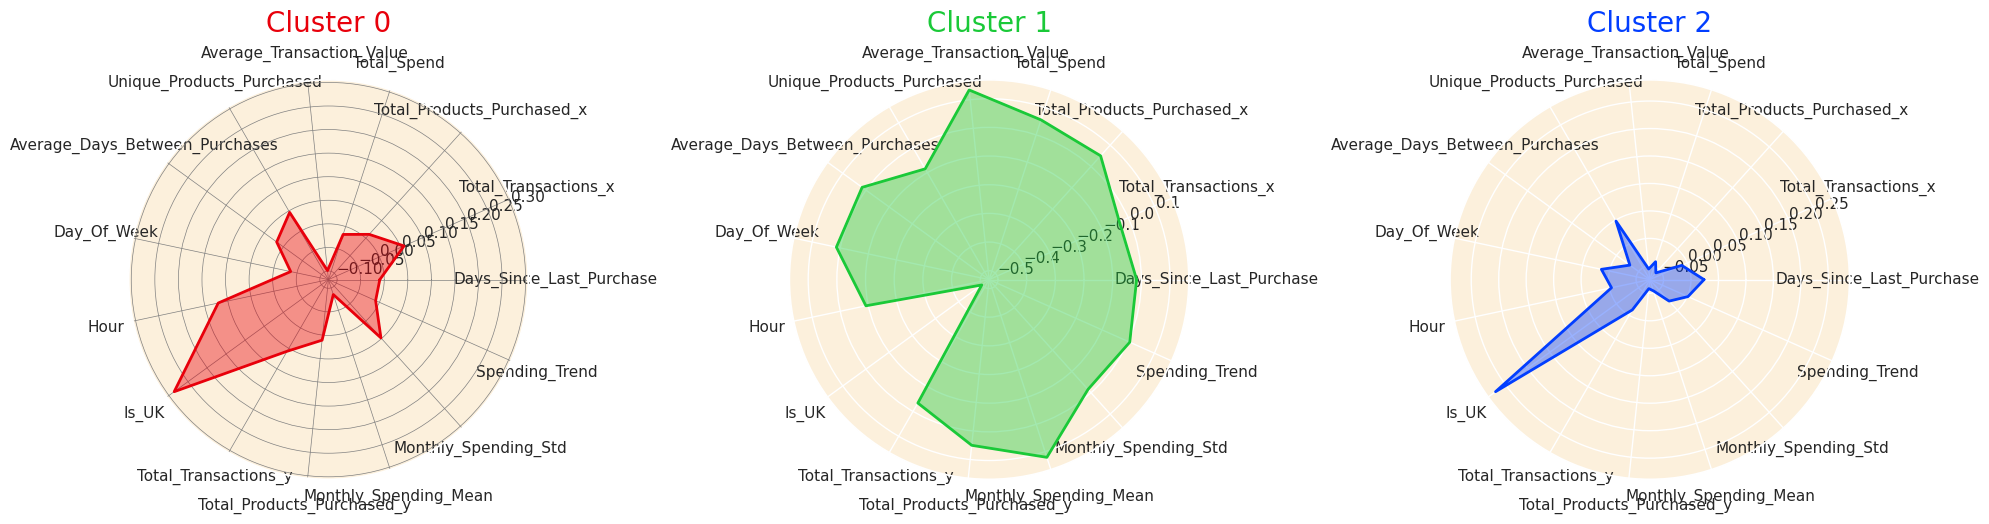

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

print("Length of new_labels:", len(new_labels))
print("Shape of customer_data_cleaned:", customer_data_cleaned.shape)

# Make sure the row counts match
if len(new_labels) != customer_data_cleaned.shape[0]:
    print("❗ Length mismatch detected. Aligning by row position using iloc.")

    # Match rows by position instead
    customer_data_cleaned_matched = customer_data_cleaned.iloc[:len(new_labels)].copy()
else:
    customer_data_cleaned_matched = customer_data_cleaned.copy()

# Match by position safely
new_labels_trimmed = new_labels[:len(customer_data_cleaned)]

# Match rows by position instead
customer_data_cleaned_matched = customer_data_cleaned.iloc[:len(new_labels_trimmed)].copy()

# ✅ Assign clusters to the matched DataFrame
customer_data_cleaned_matched['cluster'] = new_labels_trimmed

# ✅ Now use this updated frame
customer_data_cleaned = customer_data_cleaned_matched.copy()



# Use this updated frame
customer_data_cleaned = customer_data_cleaned_matched.copy()



# Make a copy to avoid in-place issues
df_customer = customer_data_cleaned.copy()

# Ensure 'CustomerID' is set as index
df_customer.set_index('CustomerID', inplace=True)

# Check if 'cluster' is present
if 'cluster' not in df_customer.columns:
    raise ValueError("'cluster' column not found in customer_data_cleaned")

# Select only numeric columns excluding 'cluster' for scaling
features_to_scale = df_customer.drop(columns='cluster')

# Standardize
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

# Create new DataFrame
df_customer_standardized = pd.DataFrame(scaled_features,
                                        columns=features_to_scale.columns,
                                        index=df_customer.index)

# Add 'cluster' column back
df_customer_standardized['cluster'] = df_customer['cluster']

# Now continue with radar chart code...



# Calculate the centroids of each cluster
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Function to create a radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    # Plot the data and fill the area
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')

    # Add a title
    ax.set_title(f'Cluster {cluster}', size=20, color=color, y=1.1)

# Set data
labels=np.array(cluster_centroids.columns)
num_vars = len(labels)

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is circular, so we need to "complete the loop" and append the start to the end
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Initialize the figure
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=3)

# Create radar chart for each cluster
for i, color in enumerate(colors):
    data = cluster_centroids.loc[i].tolist()
    data += data[:1]  # Complete the loop
    create_radar_chart(ax[i], angles, data, color, i)

# Add input data
ax[0].set_xticks(angles[:-1])
ax[0].set_xticklabels(labels[:-1])

ax[1].set_xticks(angles[:-1])
ax[1].set_xticklabels(labels[:-1])

ax[2].set_xticks(angles[:-1])
ax[2].set_xticklabels(labels[:-1])

# Add a grid
ax[0].grid(color='grey', linewidth=0.5)

# Display the plot
plt.tight_layout()
plt.show()

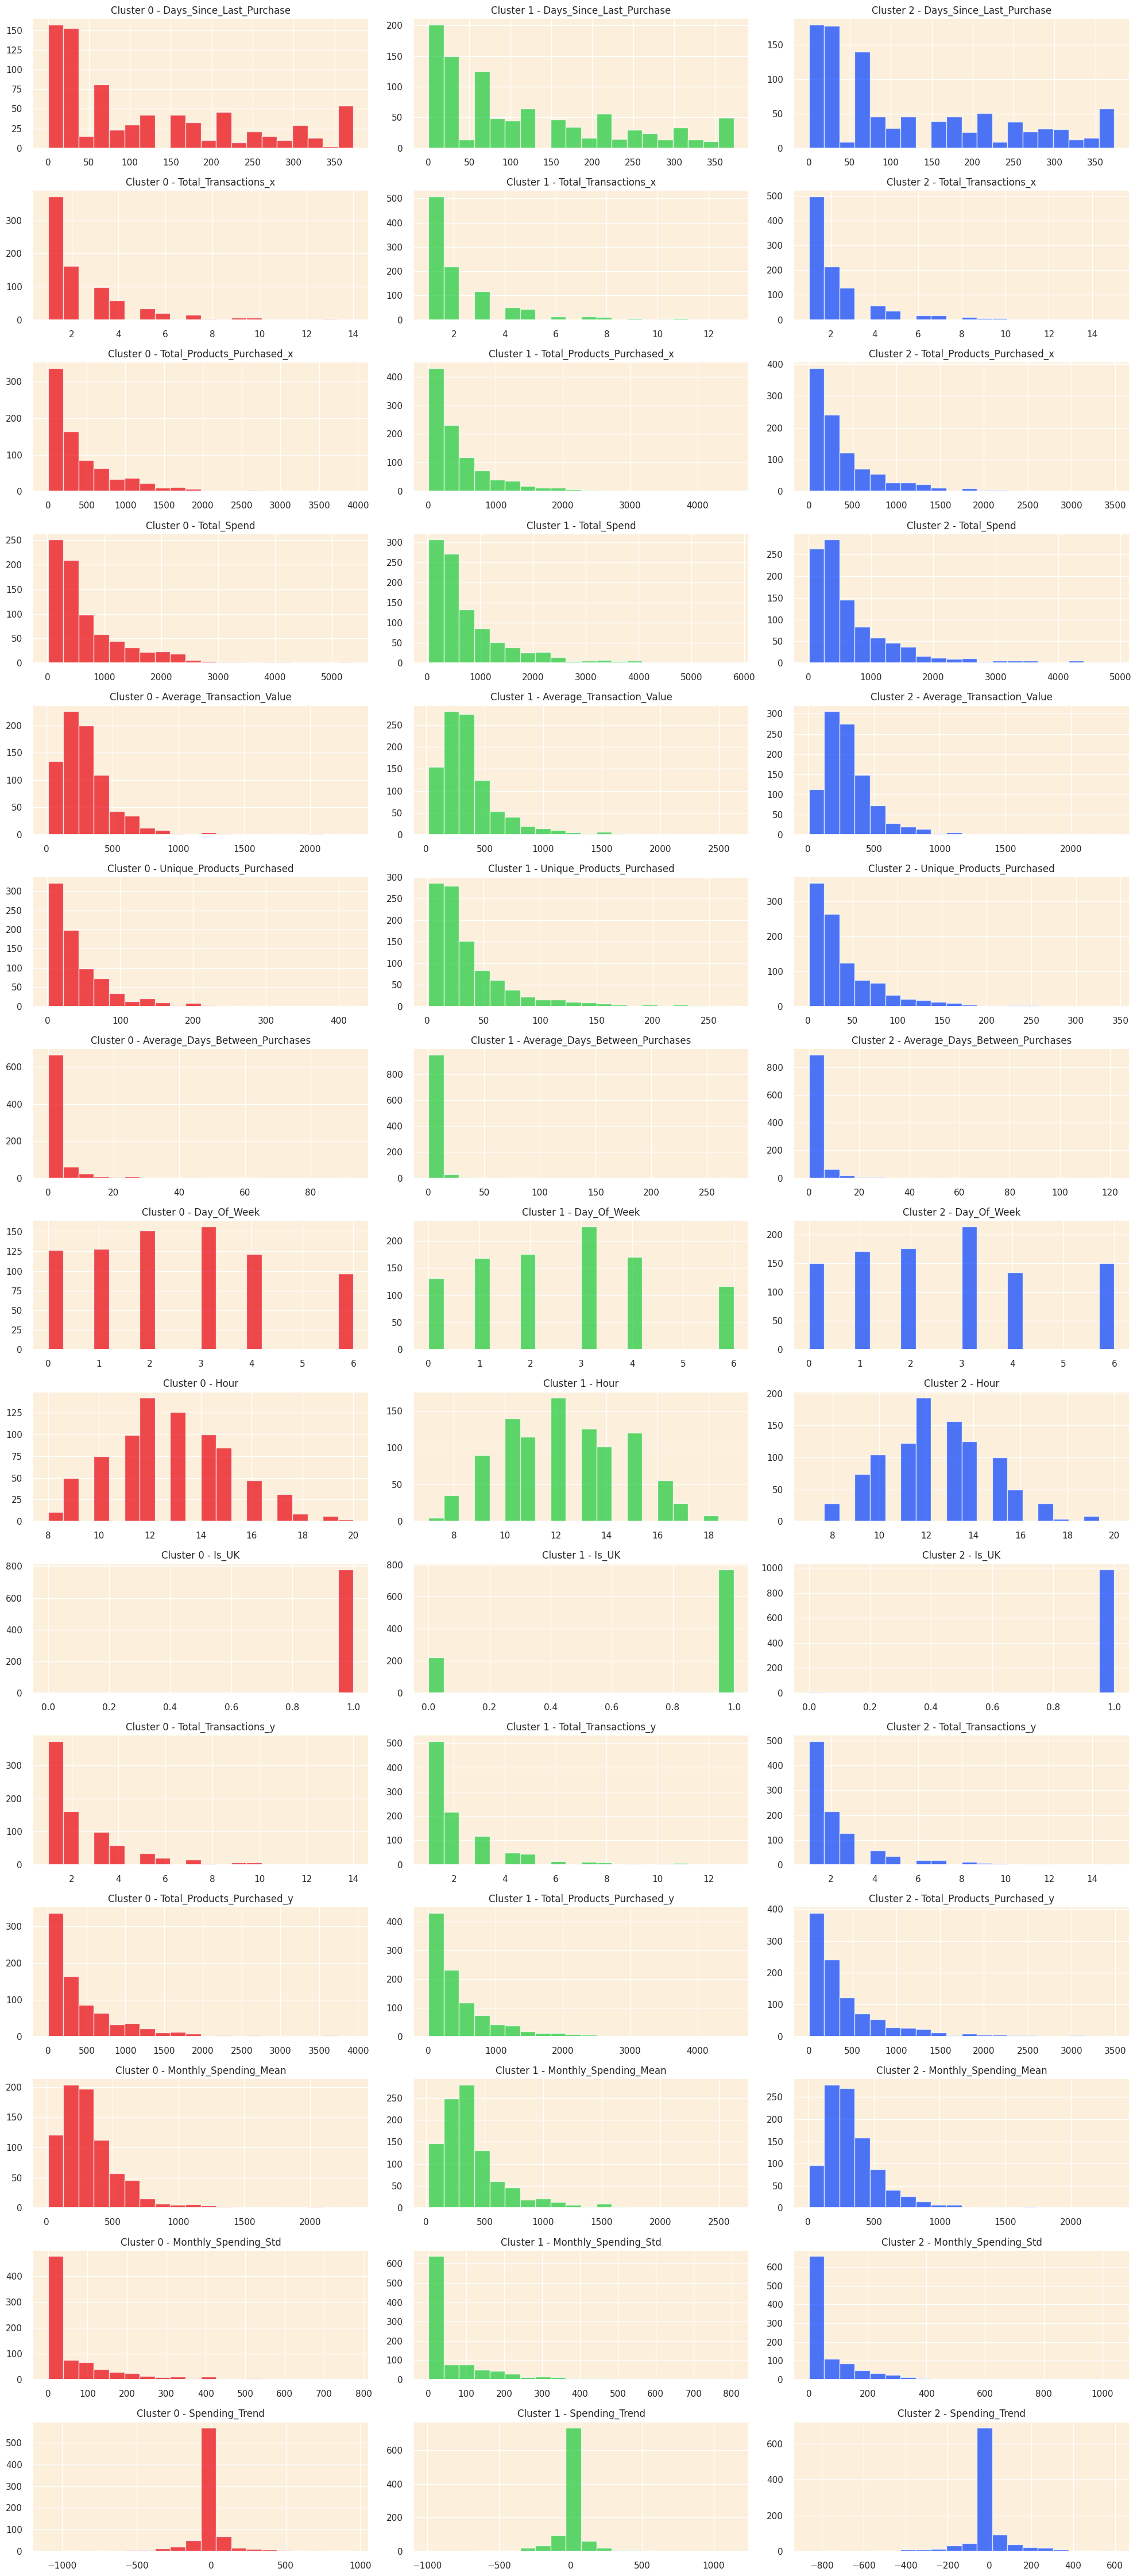

In [ ]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()

# Define some fallback colors in case 'colors' is not defined
if 'colors' not in locals():
    colors = ['#ffb74d', '#64b5f6', '#81c784', '#ba68c8', '#ff8a65', '#90caf9', '#e57373']

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))

# Ensure axes is 2D even if 1 row or 1 column
axes = np.array(axes).reshape(n_rows, n_cols)

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        ax = axes[i, j]

        if data.dropna().empty:
            ax.set_visible(False)
            continue

        ax.hist(data.dropna(), bins=20, color=colors[j % len(colors)], edgecolor='w', alpha=0.7)
        ax.set_title(f'Cluster {cluster} - {feature}', fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [ ]:
# Recommendation system
# Step 1: Extract the CustomerIDs of the outliers and remove their transactions from the main dataframe
outlier_customer_ids = outliers_data['CustomerID'].astype('float').unique()
df_filtered = df[~df['CustomerID'].isin(outlier_customer_ids)]

# Step 2: Ensure consistent data type for CustomerID across both dataframes before merging
customer_data_cleaned['CustomerID'] = customer_data_cleaned['CustomerID'].astype('float')

# Step 3: Merge the transaction data with the customer data to get the cluster information for each transaction
merged_data = df_filtered.merge(customer_data_cleaned[['CustomerID', 'cluster']], on='CustomerID', how='inner')

# Step 4: Identify the top 10 best-selling products in each cluster based on the total quantity sold
best_selling_products = merged_data.groupby(['cluster', 'StockCode', 'Description'])['Quantity'].sum().reset_index()
best_selling_products = best_selling_products.sort_values(by=['cluster', 'Quantity'], ascending=[True, False])
top_products_per_cluster = best_selling_products.groupby('cluster').head(10)

# Step 5: Create a record of products purchased by each customer in each cluster
customer_purchases = merged_data.groupby(['CustomerID', 'cluster', 'StockCode'])['Quantity'].sum().reset_index()

# Step 6: Generate recommendations for each customer in each cluster
recommendations = []
for cluster in top_products_per_cluster['cluster'].unique():
    top_products = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster]
    customers_in_cluster = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster]['CustomerID']

    for customer in customers_in_cluster:
        # Identify products already purchased by the customer
        customer_purchased_products = customer_purchases[(customer_purchases['CustomerID'] == customer) &
                                                         (customer_purchases['cluster'] == cluster)]['StockCode'].tolist()

        # Find top 3 products in the best-selling list that the customer hasn't purchased yet
        top_products_not_purchased = top_products[~top_products['StockCode'].isin(customer_purchased_products)]
        top_3_products_not_purchased = top_products_not_purchased.head(3)

        # Append the recommendations to the list
        recommendations.append([customer, cluster] + top_3_products_not_purchased[['StockCode', 'Description']].values.flatten().tolist())

# Step 7: Create a dataframe from the recommendations list and merge it with the original customer data
recommendations_df = pd.DataFrame(recommendations, columns=['CustomerID', 'cluster', 'Rec1_StockCode', 'Rec1_Description', \
                                                 'Rec2_StockCode', 'Rec2_Description', 'Rec3_StockCode', 'Rec3_Description'])
customer_data_with_recommendations = customer_data_cleaned.merge(recommendations_df, on=['CustomerID', 'cluster'], how='right')

In [ ]:
# Display 10 random rows from the customer_data_with_recommendations dataframe
customer_data_with_recommendations.set_index('CustomerID').iloc[:, -6:].sample(10, random_state=0)

,Rec1_StockCode,Rec1_Description,Rec2_StockCode,Rec2_Description,Rec3_StockCode,Rec3_Description
CustomerID,,,,,,
18250.0,84879,ASSORTED COLOUR BIRD ORNAMENT,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM
18164.0,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
13011.0,21212,PACK OF 72 RETROSPOT CAKE CASES,85099B,JUMBO BAG RED RETROSPOT,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
17315.0,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
13369.0,21212,PACK OF 72 RETROSPOT CAKE CASES,85099B,JUMBO BAG RED RETROSPOT,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
17197.0,84879,ASSORTED COLOUR BIRD ORNAMENT,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM
12821.0,21212,PACK OF 72 RETROSPOT CAKE CASES,85099B,JUMBO BAG RED RETROSPOT,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS
17235.0,84879,ASSORTED COLOUR BIRD ORNAMENT,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM
16756.0,84879,ASSORTED COLOUR BIRD ORNAMENT,22616,PACK OF 12 LONDON TISSUES,22998,TRAVEL CARD WALLET KEEP CALM


In [ ]:
# 1. Prepare RFM data (replace with your actual RFM DataFrame)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Quantity': 'sum'                                          # Monetary (approx)
}).reset_index()  # Replace this with actual RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 2. Convert to PyTorch tensor
rfm_tensor = torch.FloatTensor(rfm_scaled)

# 3. Autoencoder definition
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 4. Train the Autoencoder
dataset = TensorDataset(rfm_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

model = Autoencoder(input_dim=rfm_tensor.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(20):
    total_loss = 0
    for batch in dataloader:
        x = batch[0]
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# 5. Extract encoded (compressed) features
with torch.no_grad():
    encoded_features = model.encoder(rfm_tensor).numpy()

# 6. Cluster on encoded features
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(encoded_features)

# 7. Add back to DataFrame
rfm['Cluster'] = cluster_labels

# Optional: Evaluate clustering quality
score = silhouette_score(encoded_features, cluster_labels)
print("Silhouette Score:", score)


Epoch 1, Loss: 22.0393
Epoch 2, Loss: 4.5238
Epoch 3, Loss: 0.9208
Epoch 4, Loss: 0.9614
Epoch 5, Loss: 0.7820
Epoch 6, Loss: 0.6639
Epoch 7, Loss: 0.3648
Epoch 8, Loss: 0.5580
Epoch 9, Loss: 0.5403
Epoch 10, Loss: 0.2071
Epoch 11, Loss: 0.2002
Epoch 12, Loss: 1.1911
Epoch 13, Loss: 0.2868
Epoch 14, Loss: 0.1502
Epoch 15, Loss: 0.1486
Epoch 16, Loss: 0.1339
Epoch 17, Loss: 0.0531
Epoch 18, Loss: 0.0484
Epoch 19, Loss: 0.4445
Epoch 20, Loss: 0.1399
Silhouette Score: 0.35209477


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Assuming `encoded_features` is your bottleneck layer output from Autoencoder
# and `cluster_labels` is output from KMeans

silhouette = silhouette_score(encoded_features, cluster_labels)
davies_bouldin = davies_bouldin_score(encoded_features, cluster_labels)
calinski_harabasz = calinski_harabasz_score(encoded_features, cluster_labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")


Silhouette Score: 0.3521
Davies-Bouldin Score: 0.9811
Calinski-Harabasz Index: 1459.1080


In [ ]:
print(rfm['Cluster'].value_counts())


Cluster
2    1020
4     947
1     549
0     454
3      19
Name: count, dtype: int64


In [ ]:
### Machine Learning Models for Cluster Prediction with GridSearch ###
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 1. Remove clusters with < 5 members & re-label the clusters
min_samples = 5
# Get the valid clusters (those with more than min_samples members)
valid_clusters = rfm['Cluster'].value_counts()[rfm['Cluster'].value_counts() >= min_samples].index
# Filter the rfm DataFrame to keep only the valid clusters
rfm_filtered = rfm[rfm['Cluster'].isin(valid_clusters)].reset_index(drop=True)
# Re-label the clusters to ensure consecutive labels starting from 0
rfm_filtered['Cluster'] = rfm_filtered['Cluster'].astype('category').cat.codes

# 2. Features and Target
features = rfm_filtered.drop(columns='Cluster')
target = rfm_filtered['Cluster']

# 3. Re-label target variable with LabelEncoder (no longer needed)
# le = LabelEncoder()
# target = le.fit_transform(target)

# 4. Scale Features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

# 5. Determine adaptive n_splits for StratifiedKFold (update to use target)
min_class_size = target.value_counts().min()
n_splits = min(5, min_class_size)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 6. Train-Test Split (update to use target)
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    rfm_scaled, target, test_size=0.4, stratify=target, random_state=42
)

# 7. PCA
pca = PCA(n_components=0.75, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
rfm_scaled_pca = pca.transform(rfm_scaled)

# ... (rest of the code remains the same)


# 7. Model Hyperparameters
param_dist_rf = {
    'n_estimators': [50],
    'max_depth': [3],
    'min_samples_split': [10],
    'min_samples_leaf': [5],
    'max_features': ['sqrt'],
    'max_samples': [0.7],
    'ccp_alpha': [0.05]
}

param_dist_svm = {
    'C': [0.0001, 0.001, 0.01],
    'gamma': [1e-6, 1e-5, 1e-4],
    'kernel': ['rbf']
}

param_dist_xgb = {
    'n_estimators': 50,
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'use_label_encoder': False,
    'eval_metric': 'mlogloss'
}

# 8. Model Initialization
# Random Forest
rf_model = RandomForestClassifier(**{k: v[0] for k, v in param_dist_rf.items()}, random_state=42)

# GridSearchCV for SVM
svm_gs = GridSearchCV(SVC(random_state=42), param_dist_svm, cv=skf, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_train_pca, y_train_scaled)
svm_model = svm_gs.best_estimator_

#Linear Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# XgBoost
xgb_model = XGBClassifier(**param_dist_xgb, random_state=42)


print(f"✅ Cleaned and prepared data with n_splits={n_splits} (minimum class size = {min_class_size})")


✅ Cleaned and prepared data with n_splits=5 (minimum class size = 19)


In [ ]:
# Models to evaluate
models = {
    'RandomForest': (rf_model, X_train_scaled, X_test_scaled),
    'SVM': (svm_model, X_train_pca, X_test_pca),
    'LogisticRegression': (lr_model, X_train_scaled, X_test_scaled),
    'XGBoost': (xgb_model, X_train_pca, X_test_pca)
}



In [ ]:
# Evaluating models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define feature matrix and target
X = rfm.drop(columns='Cluster')
y = rfm['Cluster']

# 2. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Optionally apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=min(X_train_scaled.shape[1], 10))  # or however many components you need
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. Encode y labels for training/testing
from sklearn.preprocessing import LabelEncoder

y_train_scaled = y_train.reset_index(drop=True)  # if needed
y_test_scaled = y_test.reset_index(drop=True)    # if needed

# Combine all labels used in train/test to ensure LabelEncoder sees everything
combined_labels = pd.concat([y_train_scaled, y_test_scaled])

# Fit LabelEncoder on combined labels
le = LabelEncoder()
le.fit(combined_labels)

# Encode train/test sets
y_train_encoded = le.transform(y_train_scaled)
y_test_encoded = le.transform(y_test_scaled)
rfm_encoded_target = le.transform(rfm['Cluster'][rfm['Cluster'].isin(combined_labels.unique())])

# Step 4: Now print shapes
print("X_train shape:", X_train.shape)
print("y_train_encoded shape:", y_train_encoded.shape)

# Make sure models dict uses correct datasets
models = {
    'RandomForest': (rf_model, X_train_scaled, X_test_scaled),
    'SVM': (svm_model, X_train_pca, X_test_pca),
    'LogisticRegression': (lr_model, X_train_scaled, X_test_scaled),
    'XGBoost': (xgb_model, X_train_pca, X_test_pca)
}

# Evaluate
results = {}
for name, (model, X_train, X_test) in models.items():
    print(f"\n--- Evaluating {name} ---")

    if name == 'XGBoost':
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)
        cross_val_data = X_train_pca
        cross_val_target = y_train_encoded
        cross_val_model = model
        test_labels = y_test_encoded
    else:
        model.fit(X_train, y_train_scaled)
        y_pred = model.predict(X_test)
        test_labels = y_test_scaled

        if name == 'SVM':
            cross_val_data = rfm_scaled_pca
            cross_val_target = rfm['Cluster']
            cross_val_model = GridSearchCV(SVC(random_state=42), param_dist_svm, cv=skf, scoring='accuracy', n_jobs=-1).fit(cross_val_data, cross_val_target).best_estimator_
        else:
            cross_val_data = rfm_scaled
            cross_val_target = rfm['Cluster']
            cross_val_model = model

    # Cross-validation
    cross_val_scores = cross_val_score(
        cross_val_model, cross_val_data, cross_val_target,
        cv=skf, scoring='accuracy', n_jobs=-1
    )

    # Store metrics
    results[name] = {
        'Accuracy': accuracy_score(test_labels, y_pred),
        'Cross-Val Accuracy': cross_val_scores.mean(),
        'Precision': precision_score(test_labels, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(test_labels, y_pred, average='weighted', zero_division=0),
        'F1 Score': f1_score(test_labels, y_pred, average='weighted', zero_division=0)
    }

    # Print report
    print(f"{name} Classification Report:\n{classification_report(test_labels, y_pred, zero_division=0)}")
    print(f"{name} Confusion Matrix:\n{confusion_matrix(test_labels, y_pred)}")

# Show best SVM params if applicable
if 'SVM' in models:
    print(f"\nBest params for SVM: {svm_gs.best_params_}")


X_train shape: (2391, 4)
y_train_encoded shape: (2391,)

--- Evaluating RandomForest ---
RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        91
           1       0.92      0.97      0.95       110
           2       0.91      0.98      0.95       204
           3       0.00      0.00      0.00         4
           4       0.97      0.87      0.92       189

    accuracy                           0.94       598
   macro avg       0.76      0.77      0.76       598
weighted avg       0.94      0.94      0.94       598

RandomForest Confusion Matrix:
[[ 91   0   0   0   0]
 [  2 107   0   0   1]
 [  0   0 200   0   4]
 [  0   0   4   0   0]
 [  0   9  15   0 165]]

--- Evaluating SVM ---
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        91
           1       0.00      0.00      0.00       110
           2       0.34  

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:46:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        91
           1       0.93      0.91      0.92       110
           2       0.96      0.98      0.97       204
           3       1.00      1.00      1.00         4
           4       0.95      0.93      0.94       189

    accuracy                           0.95       598
   macro avg       0.96      0.96      0.96       598
weighted avg       0.95      0.95      0.95       598

XGBoost Confusion Matrix:
[[ 88   2   0   0   1]
 [  3 100   3   0   4]
 [  0   0 199   0   5]
 [  0   0   0   4   0]
 [  2   6   5   0 176]]

Best params for SVM: {'C': 0.0001, 'gamma': 1e-06, 'kernel': 'rbf'}


In [ ]:
# Visualize Evaluation Metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
metrics = ['Accuracy', 'Cross-Val Accuracy', 'Precision', 'Recall', 'F1 Score']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate, LSTM, TimeDistributed, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

In [ ]:
# =========================
# Cluster Classification Models
# =========================
# Ensure column names are clean and 'CustomerID' exists
df.columns = df.columns.str.strip()
if 'CustomerID' not in df.columns:
    raise KeyError("The column 'CustomerID' is not present in the dataframe.")
df = df.dropna(subset=['CustomerID'])

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm['Cluster'] = pd.qcut(rfm['Recency'], q=4, labels=False)

features = rfm.drop(columns='Cluster')
target = rfm['Cluster']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    rfm_scaled, target, test_size=0.4, stratify=target, random_state=42
)

In [ ]:
pca = PCA(n_components=0.75, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
rfm_scaled_pca = pca.transform(rfm_scaled)

# Tuned hyperparameters to prevent overfitting
param_dist_rf = {
    'n_estimators': [50],
    'max_depth': [5],
    'min_samples_split': [10],
    'min_samples_leaf': [10],
    'max_features': ['sqrt'],
    'max_samples': [0.8],
    'ccp_alpha': [0.05]
}

param_dist_svm = {
    'C': [0.01, 0.1, 1],
    'gamma': [1e-4, 1e-3],
    'kernel': ['rbf']
}

param_dist_xgb = {
    'n_estimators': 50,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'use_label_encoder': False,
    'eval_metric': 'mlogloss'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(**{k: v[0] for k, v in param_dist_rf.items()}, random_state=42)
rf_model.fit(X_train_pca, y_train_scaled)
y_pred_rf = rf_model.predict(X_test_pca)
print("\n📊 Random Forest Results")
print("Accuracy:", accuracy_score(y_test_scaled, y_pred_rf))
print(classification_report(y_test_scaled, y_pred_rf))

# SVM\svm_gs = GridSearchCV(SVC(random_state=42), param_dist_svm, cv=skf, scoring='accuracy', n_jobs=-1)
svm_gs.fit(X_train_pca, y_train_scaled)
svm_model = svm_gs.best_estimator_
y_pred_svm = svm_model.predict(X_test_pca)
print("\n📊 SVM Results")
print("Accuracy:", accuracy_score(y_test_scaled, y_pred_svm))
print(classification_report(y_test_scaled, y_pred_svm))

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=0.5, penalty='l2', solver='lbfgs', random_state=42)
lr_model.fit(X_train_pca, y_train_scaled)
y_pred_lr = lr_model.predict(X_test_pca)
print("\n📊 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test_scaled, y_pred_lr))
print(classification_report(y_test_scaled, y_pred_lr))

# XGBoost
xgb_model = XGBClassifier(**param_dist_xgb, random_state=42)
xgb_model.fit(X_train_pca, y_train_scaled)
y_pred_xgb = xgb_model.predict(X_test_pca)
print("\n📊 XGBoost Results")
print("Accuracy:", accuracy_score(y_test_scaled, y_pred_xgb))
print(classification_report(y_test_scaled, y_pred_xgb))



📊 Random Forest Results
Accuracy: 0.822742474916388
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       314
           1       0.80      0.66      0.72       286
           2       0.73      0.92      0.81       305
           3       0.90      0.99      0.94       291

    accuracy                           0.82      1196
   macro avg       0.83      0.82      0.82      1196
weighted avg       0.83      0.82      0.82      1196


📊 SVM Results
Accuracy: 0.2625418060200669
              precision    recall  f1-score   support

           0       0.26      1.00      0.42       314
           1       0.00      0.00      0.00       286
           2       0.00      0.00      0.00       305
           3       0.00      0.00      0.00       291

    accuracy                           0.26      1196
   macro avg       0.07      0.25      0.10      1196
weighted avg       0.07      0.26      0.11      1196


📊 Logistic Regression Results
Ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/xgboost/c

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect model evaluation metrics
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

metrics_summary = []
metrics_summary.append(get_metrics(y_test_scaled, y_pred_rf, 'Random Forest'))
metrics_summary.append(get_metrics(y_test_scaled, y_pred_svm, 'SVM'))
metrics_summary.append(get_metrics(y_test_scaled, y_pred_lr, 'Logistic Regression'))
metrics_summary.append(get_metrics(y_test_scaled, y_pred_xgb, 'XGBoost'))

# Create a summary DataFrame
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.sort_values(by='Accuracy', ascending=False)

print("\n✅ Model Performance Comparison:")
print(metrics_df)

# Highlight the best model
best_model = metrics_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']} with Accuracy: {best_model['Accuracy']:.4f}")



✅ Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score
2  Logistic Regression  0.916388   0.919424  0.916388  0.917009
3              XGBoost  0.912207   0.914120  0.912207  0.912707
0        Random Forest  0.822742   0.829980  0.822742  0.819080
1                  SVM  0.262542   0.068928  0.262542  0.109190

🏆 Best Model: Logistic Regression with Accuracy: 0.9164


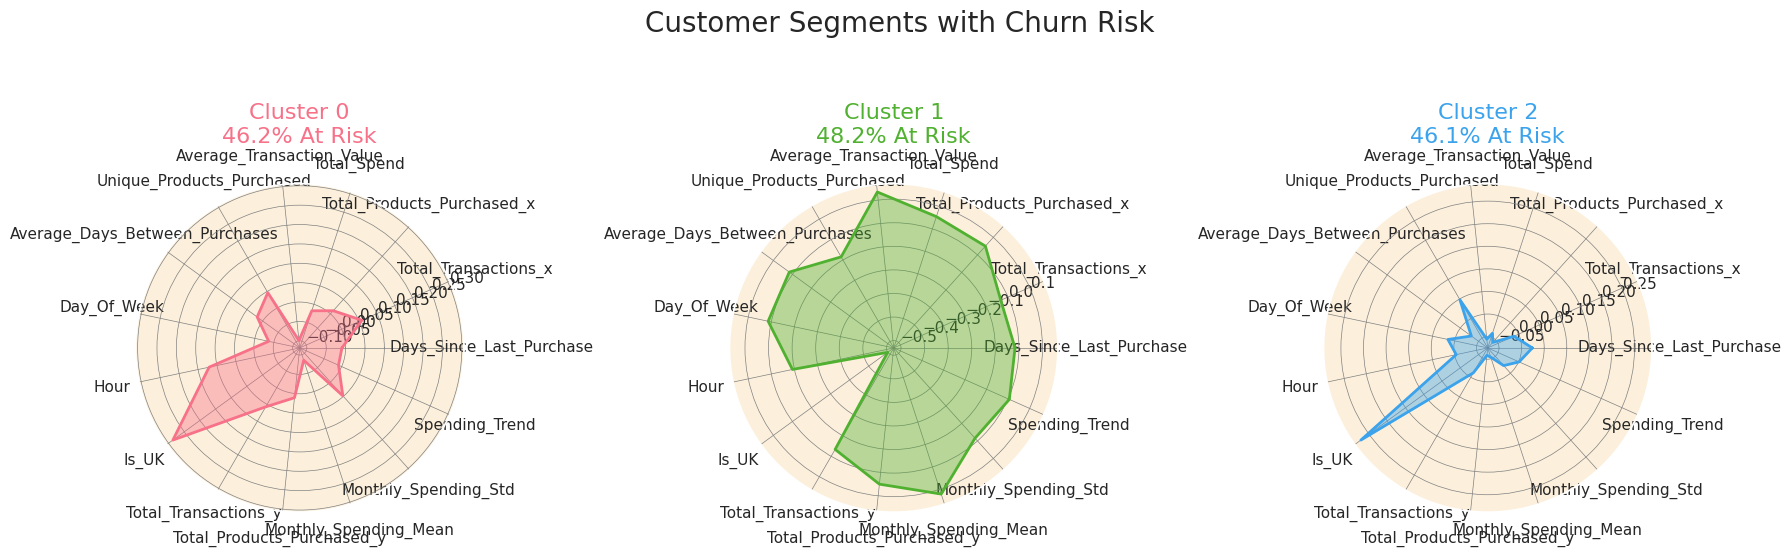

In [ ]:
# Logistic regression for Churn Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

# -----------------------------
# STEP 1: RFM + Churn Label
# -----------------------------
reference_date = df['InvoiceDate'].max()  # Set the reference date

# Create RFM features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Quantity': 'sum'                                          # Monetary (approx)
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Define churn: Customers who haven’t purchased in >90 days
rfm['churn'] = (rfm['Recency'] > 90).astype(int)

# -----------------------------
# STEP 2: Logistic Regression
# -----------------------------
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

churn_model = LogisticRegression()
churn_model.fit(X_train, y_train)

# Predict churn for full dataset
rfm['churn_pred'] = churn_model.predict(X)

# -----------------------------
# Retrieving the original customer_data_cleaned
# Assuming the variable is still in the environment.
df_customer = customer_data_cleaned.copy()

# Change the data type of 'CustomerID' in either df_customer or rfm to match the other
df_customer['CustomerID'] = df_customer['CustomerID'].astype(float)  # Or rfm['CustomerID'].astype(str)

# Now proceed with the merge
df_customer = df_customer.merge(rfm[['CustomerID', 'churn_pred']], on='CustomerID', how='left')

# -----------------------------
# STEP 4: Churn Stats Per Cluster
# -----------------------------
churn_stats = df_customer.groupby('cluster')['churn_pred'].agg(['mean', 'count'])
churn_stats['percent_churn'] = churn_stats['mean'] * 100

# -----------------------------
# STEP 5: Radar Chart Integration
# -----------------------------
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

def create_radar_chart(ax, angles, data, color, cluster, churn_rate):
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    ax.set_title(f'Cluster {cluster}\n{churn_rate:.1f}% At Risk', size=16, color=color, y=1.1)

labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

n_clusters = cluster_centroids.shape[0]
fig, axes = plt.subplots(figsize=(6 * n_clusters, 6), subplot_kw=dict(polar=True), ncols=n_clusters)

# Set colors
colors = sns.color_palette("husl", n_clusters)

# Create radar charts
for i in range(n_clusters):
    ax = axes[i] if n_clusters > 1 else axes
    data = cluster_centroids.loc[i].tolist()
    data += data[:1]
    churn_rate = churn_stats.loc[i, 'percent_churn']
    create_radar_chart(ax, angles, data, colors[i], i, churn_rate)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1])
    ax.grid(color='grey', linewidth=0.5)

plt.suptitle("Customer Segments with Churn Risk", size=20)
plt.tight_layout()
plt.show()

In [ ]:
# Assume you've already scaled and (for some models) PCA-transformed your RFM features

# Define model input features
X_rf = rfm_scaled                      # For RandomForest and LogisticRegression
X_svm_xgb = rfm_scaled_pca            # For SVM and XGBoost using PCA-transformed features

# Encode the target for XGBoost
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(rfm['Cluster'])  # For training

# 1. RandomForest
rf_model.fit(X_rf, rfm['Cluster'])
rf_preds = rf_model.predict(X_rf)
rfm['Cluster_RF'] = rf_preds

# 2. SVM
svm_model.fit(X_svm_xgb, rfm['Cluster'])
svm_preds = svm_model.predict(X_svm_xgb)
rfm['Cluster_SVM'] = svm_preds

# 3. Logistic Regression
lr_model.fit(X_rf, rfm['Cluster'])
lr_preds = lr_model.predict(X_rf)
rfm['Cluster_LR'] = lr_preds

# 4. XGBoost
xgb_model = XGBClassifier(**param_dist_xgb, random_state=42, verbosity=0)
xgb_model.fit(X_svm_xgb, y)
xgb_preds = xgb_model.predict(X_svm_xgb)
rfm['Cluster_XGB'] = le.inverse_transform(xgb_preds)  # Convert back to original cluster labels


In [ ]:
rfm['Cluster_LR'] = lr_preds


In [ ]:
# View sample predictions
print(rfm[['CustomerID', 'Cluster_LR']].head())  # Adjust 'CustomerID' to your customer identifier column


   CustomerID  Cluster_LR
0     12347.0           0
1     12348.0           3
2     12350.0           3
3     12352.0           1
4     12355.0           3


In [ ]:
# Count of customers in each segment
print(rfm['Cluster_LR'].value_counts())


Cluster_LR
1    846
3    759
2    701
0    683
Name: count, dtype: int64


In [ ]:
# Recommendation & Insights: Top Products and Customer Preferences
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Compute total quantity sold per product
product_sales = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)

In [ ]:
# Top 10 best selling products
top_10_best = product_sales.head(10)
print("Top 10 Best Selling Products:\n", top_10_best)


Top 10 Best Selling Products:
 StockCode
23843     80995
84077     24586
22197     20690
85099B    20586
84879     18033
85123A    17493
21915     13963
21212     13203
22492     12991
22616     10620
Name: Quantity, dtype: int64


In [ ]:
# Top 10 least selling products (excluding negative or zero quantities)
least_10 = product_sales[product_sales > 0].tail(10)
print("\nTop 10 Least Selling Products:\n", least_10)


Top 10 Least Selling Products:
 StockCode
85135A    1
85136B    1
90179C    1
90181A    1
90183C    1
90185A    1
90185B    1
90199D    1
90202C    1
90202B    1
Name: Quantity, dtype: int64


In [ ]:
# Top 10 Customer-Product purchases
customer_product = df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Customer-Product Purchases:\n", customer_product)



Top 10 Customer-Product Purchases:
 CustomerID  StockCode
16446.0     23843        80995
16333.0     21915         7560
17949.0     22197         6140
16333.0     84077         6048
12931.0     84879         5048
16308.0     16014         5000
18102.0     22189         4206
16029.0     20971         3888
16210.0     21137         3600
17381.0     22616         3336
Name: Quantity, dtype: int64


<ipython-input-98-6844c9dab9fc>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_best.index, y=top_10_best.values, palette='crest')


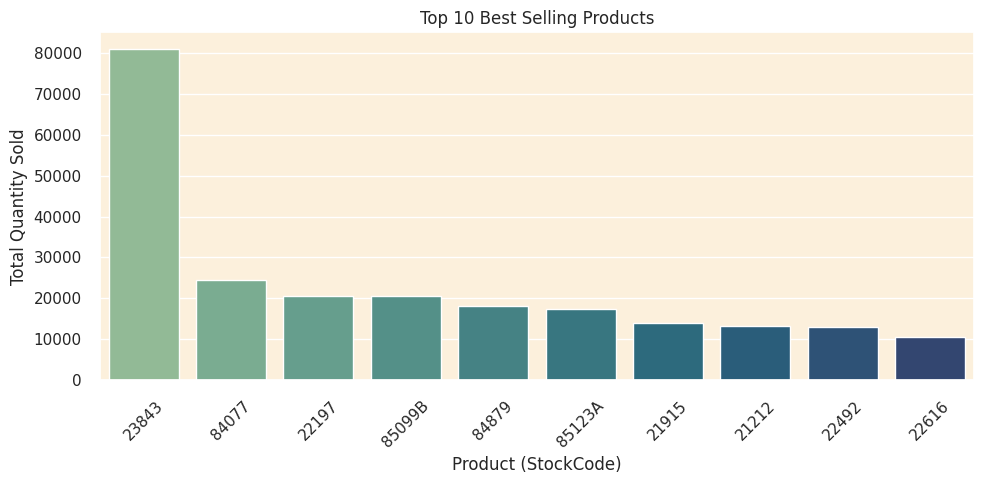

In [ ]:
# Visualization: Top 10 Best Selling Products
plt.figure(figsize=(10,5))
sns.barplot(x=top_10_best.index, y=top_10_best.values, palette='crest')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product (StockCode)')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-99-bbe151e63863>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=least_10.index, y=least_10.values, palette='flare')


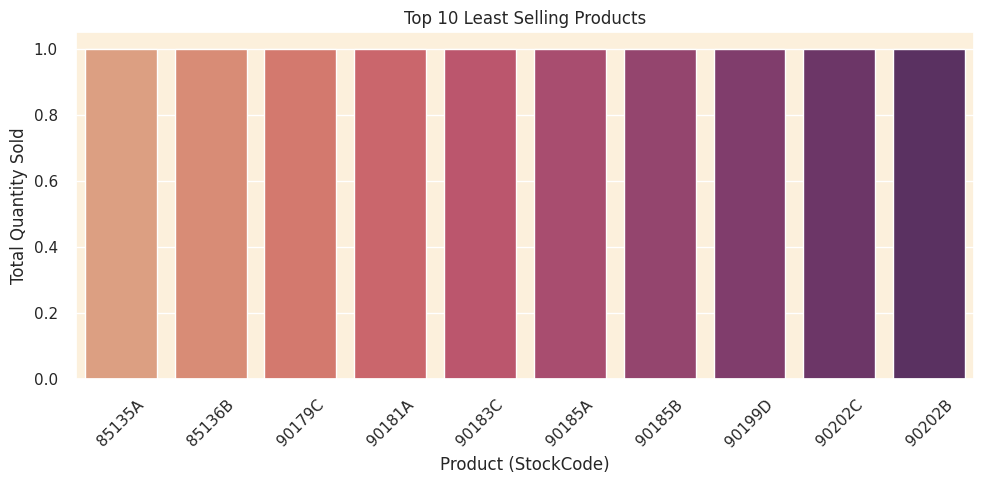

In [ ]:
# Visualization: Top 10 Least Selling Products
plt.figure(figsize=(10,5))
sns.barplot(x=least_10.index, y=least_10.values, palette='flare')
plt.title('Top 10 Least Selling Products')
plt.xlabel('Product (StockCode)')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Recommender System by Country
country_product_group = df.groupby(['Country', 'StockCode'])['Quantity'].sum().reset_index()


In [ ]:
# Sorting within each country and selecting Top 3 products
top_products_country = country_product_group.sort_values(['Country', 'Quantity'], ascending=[True, False])

In [ ]:
# Get the top 3 products for each country
top_3_per_country = top_products_country.groupby('Country').head(3)

# Merging with product descriptions for better readability
top_3_per_country = top_3_per_country.merge(df[['StockCode', 'Description']].drop_duplicates(), on='StockCode', how='left')

In [ ]:
# Sample: Display Top 3 product recommendations for selected countries
sample_countries = ['United Kingdom', 'Germany', 'France', 'Australia', 'Netherlands', 'Norway', 'EIRE']

In [ ]:
print("\n📦 Top 3 Product Recommendations per Country (Sample):\n")
for country in sample_countries:
    print(f"Country: {country}")
    display(top_3_per_country[top_3_per_country['Country'] == country][['StockCode', 'Description', 'Quantity']])


📦 Top 3 Product Recommendations per Country (Sample):

Country: United Kingdom


,StockCode,Description,Quantity
105,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
106,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,22761
107,22197,SMALL POPCORN HOLDER,19355
108,22197,POPCORN HOLDER,19355


Country: Germany


,StockCode,Description,Quantity
43,15036,ASSORTED COLOURS SILK FAN,816
44,22629,SPACEBOY LUNCH BOX,516
45,22326,ROUND SNACK BOXES SET OF4 WOODLAND,501


Country: France


...

,StockCode,Description,Quantity
67,23084,RABBIT NIGHT LIGHT,1680
68,22629,SPACEBOY LUNCH BOX,1420
69,21212,PACK OF 72 RETROSPOT CAKE CASES,1368


Country: Norway


,StockCode,Description,Quantity
70,22197,SMALL POPCORN HOLDER,344
71,22197,POPCORN HOLDER,344
72,16008,SMALL FOLDING SCISSOR(POINTED EDGE),264
73,22693,GROW A FLYTRAP OR SUNFLOWER IN TIN,216


Country: EIRE


,StockCode,Description,Quantity
28,17084R,ASSORTED INCENSE PACK,1440
29,84212,"ASSORTED FLOWER COLOUR ""LEIS""",960
30,21790,VINTAGE SNAP CARDS,868


In [ ]:
# ----------------- Recommender System by CustomerID ------------------

# Grouping by CustomerID and StockCode to find total quantity bought
customer_product_df = df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().reset_index()
customer_product_df.rename(columns={'StockCode': 'Product'}, inplace=True)

In [ ]:
# Top N products per customer
top_n = 5
top_products_per_customer = customer_product_df.sort_values(['CustomerID', 'Quantity'], ascending=[True, False])
top_products_per_customer = top_products_per_customer.groupby('CustomerID').head(top_n)

In [ ]:
# Create recommendation dictionary
customer_recommendations_dict = top_products_per_customer.groupby('CustomerID')['Product'].apply(list).to_dict()


In [ ]:
# Show sample customer recommendations
sample_customers = list(customer_recommendations_dict.keys())[:5]  # display few customers
for customer in sample_customers:
    print(f"\nRecommended products for Customer {int(customer)}:")
    for product in customer_recommendations_dict[customer]:
        print(f" - {product}")


Recommended products for Customer 12347:
 - 23076
 - 84558A
 - 22492
 - 21731
 - 21975

Recommended products for Customer 12348:
 - 23078
 - 23077
 - 23076
 - 22437

Recommended products for Customer 12350:
 - 22348
 - 20615
 - 20652
 - 21171
 - 21832

Recommended products for Customer 12352:
 - 23088
 - 23367
 - 23368
 - 21669
 - 22982

Recommended products for Customer 12355:
 - 23076
 - 23077
 - 22693
 - 85040A
 - 22649


In [ ]:
import tensorflow as tf
print(tf.__version__)  # Make sure it's 2.x


2.18.0


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dot, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate
from tensorflow.keras.optimizers import Adam

In [ ]:
# Neural Collaborative Filtering Recommendation Integration

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [ ]:
# Define Dataset class
class NCFDataset(Dataset):
    def __init__(self, user_tensor, item_tensor, target_tensor):
        self.user_tensor = user_tensor
        self.item_tensor = item_tensor
        self.target_tensor = target_tensor

    def __getitem__(self, index):
        return self.user_tensor[index], self.item_tensor[index], self.target_tensor[index]

    def __len__(self):
        return self.user_tensor.size(0)

In [ ]:


# Define NCF model
class NCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim=64):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        vector = torch.cat([user_emb, item_emb], dim=-1)
        return self.fc_layers(vector).squeeze()



In [ ]:
# Encode CustomerID and StockCode
user_enc = LabelEncoder()
item_enc = LabelEncoder()

# Assuming 'df' is your DataFrame containing transactions
transactions_df = df.copy()  # Create a copy to avoid modifying the original DataFrame

user_enc.fit(transactions_df['CustomerID'])
item_enc.fit(transactions_df['StockCode'])


transactions_df['user'] = user_enc.transform(transactions_df['CustomerID'])
transactions_df['item'] = item_enc.transform(transactions_df['StockCode'])

print(user_enc.classes_[:10])  # Should print first 10 unique CustomerIDs
n_users = transactions_df['user'].nunique()
n_items = transactions_df['item'].nunique()

[12347. 12348. 12350. 12352. 12355. 12356. 12357. 12358. 12359. 12362.]


In [ ]:
# Prepare user-item matrix
user_item_matrix = transactions_df.groupby(['user', 'item']).size().reset_index(name='interaction')
user_tensor = torch.LongTensor(user_item_matrix['user'].values)
item_tensor = torch.LongTensor(user_item_matrix['item'].values)
target_tensor = torch.FloatTensor(user_item_matrix['interaction'].values > 0)

In [ ]:
# Load dataset and model
dataset = NCFDataset(user_tensor, item_tensor, target_tensor)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

In [ ]:
num_users = transactions_df['user'].nunique()
num_items = transactions_df['item'].nunique()
model = NCF(num_users, num_items)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)



In [ ]:
import random
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Step 1: Create Positive Interactions
positive_df = transactions_df.groupby(['user', 'item']).size().reset_index(name='interaction')
positive_df['interaction'] = 1

# Step 2: Create Negative Interactions (Sampling user-item pairs that don't exist)
all_user_item_pairs = set((u, i) for u in transactions_df['user'].unique()
                          for i in transactions_df['item'].unique())
positive_pairs = set(zip(positive_df['user'], positive_df['item']))

negative_pairs = list(all_user_item_pairs - positive_pairs)
negative_sample = random.sample(negative_pairs, len(positive_df))  # balance dataset
negative_df = pd.DataFrame(negative_sample, columns=['user', 'item'])
negative_df['interaction'] = 0

# Step 3: Combine and Shuffle
full_df = pd.concat([positive_df, negative_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 4: Split data
train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['interaction'])

# Convert to tensors
train_dataset = NCFDataset(
    torch.LongTensor(train_df['user'].values),
    torch.LongTensor(train_df['item'].values),
    torch.FloatTensor(train_df['interaction'].values)
)

test_dataset = NCFDataset(
    torch.LongTensor(test_df['user'].values),
    torch.LongTensor(test_df['item'].values),
    torch.FloatTensor(test_df['interaction'].values)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512)





In [ ]:
# Step 5: Train Model
model = NCF(num_users, num_items)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(50):
    model.train()
    total_loss = 0
    for user_batch, item_batch, target_batch in train_loader:
        optimizer.zero_grad()
        output = model(user_batch, item_batch).squeeze()
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} - Loss: {total_loss:.4f}")



Epoch 1 - Loss: 276.4413
Epoch 2 - Loss: 246.3502
Epoch 3 - Loss: 222.7804
Epoch 4 - Loss: 207.9208
Epoch 5 - Loss: 198.4963
Epoch 6 - Loss: 191.7642
Epoch 7 - Loss: 186.9725
Epoch 8 - Loss: 183.9230
Epoch 9 - Loss: 181.2039
Epoch 10 - Loss: 179.3225
Epoch 11 - Loss: 177.7753
Epoch 12 - Loss: 176.3885
Epoch 13 - Loss: 175.0562
Epoch 14 - Loss: 174.0506
Epoch 15 - Loss: 173.1681
Epoch 16 - Loss: 172.4166
Epoch 17 - Loss: 171.4937
Epoch 18 - Loss: 170.7112
Epoch 19 - Loss: 170.0387
Epoch 20 - Loss: 169.0429
Epoch 21 - Loss: 168.3286
Epoch 22 - Loss: 167.7286
Epoch 23 - Loss: 166.9233
Epoch 24 - Loss: 165.9974
Epoch 25 - Loss: 165.3768
Epoch 26 - Loss: 164.5756
Epoch 27 - Loss: 164.0066
Epoch 28 - Loss: 162.8859
Epoch 29 - Loss: 162.1378
Epoch 30 - Loss: 161.5511
Epoch 31 - Loss: 160.2310
Epoch 32 - Loss: 159.5184
Epoch 33 - Loss: 158.8680
Epoch 34 - Loss: 158.1934
Epoch 35 - Loss: 157.0659
Epoch 36 - Loss: 156.1957
Epoch 37 - Loss: 155.6340
Epoch 38 - Loss: 154.8957
Epoch 39 - Loss: 153.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Step 6: Evaluate
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for user_batch, item_batch, target_batch in test_loader:
        preds = model(user_batch, item_batch).squeeze()
        preds = (preds > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target_batch.cpu().numpy())

print("\n🔍 Evaluation Metrics:")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, digits=4))







🔍 Evaluation Metrics:
Accuracy: 0.7735
              precision    recall  f1-score   support

         0.0     0.7733    0.7739    0.7736     26356
         1.0     0.7737    0.7732    0.7734     26355

    accuracy                         0.7735     52711
   macro avg     0.7735    0.7735    0.7735     52711
weighted avg     0.7735    0.7735    0.7735     52711



In [ ]:
# Aggregate: 1 if the customer bought the product at least once
user_item_matrix = df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().unstack().fillna(0)
user_item_matrix = (user_item_matrix > 0).astype(int)  # binary interaction (bought or not)


In [ ]:
import torch

def recommend_products(customer_id, top_n=5):
    # Encode customer
    customer_encoded = user_enc.transform([customer_id])[0]
    print(f"Encoded customer ID: {customer_encoded}")

    # Create tensors for all item IDs
    item_ids = np.arange(n_items)
    user_ids = np.full(n_items, customer_encoded)

    # Convert to PyTorch tensors
    user_tensor = torch.tensor(user_ids, dtype=torch.long)
    item_tensor = torch.tensor(item_ids, dtype=torch.long)

    # Make prediction
    model.eval()  # Put model in eval mode
    with torch.no_grad():
        preds = model(user_tensor, item_tensor).numpy().flatten()

    # Get top N items
    top_items = preds.argsort()[-top_n:][::-1]
    recommended_stockcodes = item_enc.inverse_transform(top_items)

    return recommended_stockcodes


In [ ]:
sample_customer_id = user_enc.classes_[500]  # or any index within range
recommend_products(sample_customer_id)



Encoded customer ID: 500


array(['21080', '22423', '22427', '22149', '23203'], dtype=object)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense as KDense

In [ ]:
# Check how many samples you have in the dataset:
print(df.shape)

# Now let's check X_train and y_train shapes:
print(X_train.shape)
print(y_train.shape)

(165696, 15)
(2391, 4)
(2391,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from keras.layers import Input

lstm_model = Sequential()
lstm_model.add(Input(shape=(3, 1)))
lstm_model.add(LSTM(50, activation='relu'))

lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, verbose=1, batch_size=32)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3676.9028
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1367.6212
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 603.0850
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 586.0496
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 403.7701
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 808.4388
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 588.8504
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 127.3414
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 118.3489
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 105.4975


In [ ]:
loss = lstm_model.evaluate(X_test, y_test)
print(f"\n📉 Churn Prediction / CLV LSTM Model Evaluation Loss: {loss:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 12.4327

📉 Churn Prediction / CLV LSTM Model Evaluation Loss: 16.4806


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict future quantities
y_pred_lstm = lstm_model.predict(X_test, verbose=0)

# Define churn threshold: if predicted quantity < 1 → churn
y_pred_lstm_labels = (y_pred_lstm < 1).astype(int)
y_test_labels = (y_test < 1).astype(int)

# Metrics
print("\n📉 LSTM Churn Classification Metrics:")
print("Accuracy:", accuracy_score(y_test_labels, y_pred_lstm_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred_lstm_labels))
print("Classification Report:\n", classification_report(y_test_labels, y_pred_lstm_labels))



📉 LSTM Churn Classification Metrics:
Accuracy: 0.5418060200668896
Confusion Matrix:
 [[209 251]
 [ 23 115]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.45      0.60       460
           1       0.31      0.83      0.46       138

    accuracy                           0.54       598
   macro avg       0.61      0.64      0.53       598
weighted avg       0.77      0.54      0.57       598



In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Assume y_pred_lstm contains probabilities and y_test_labels are the true labels

thresholds = np.arange(0.1, 0.91, 0.01)
best_f1 = 0
best_thresh = 0.5

for thresh in thresholds:
    preds = (y_pred_lstm > thresh).astype(int)
    score = f1_score(y_test_labels, preds, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

# Use the best threshold to finalize predictions
y_pred_lstm_labels = (y_pred_lstm > best_thresh).astype(int)

print(f"Best Threshold: {best_thresh:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")


Best Threshold: 0.10
Best F1 Score: 0.2775
